# Evaluation

In [2]:
%load_ext autoreload
%autoreload 2
from typing import Literal

import seaborn as sns
import matplotlib.pyplot as plt


sns.set_context("notebook", font_scale=0.1)
plt.style.use("default")
plt.rc("figure", dpi=150)
plt.rcParams["axes.titlesize"] = 10
plt.rcParams["axes.labelsize"] = 9
plt.rcParams["xtick.labelsize"] = 8
plt.rcParams["ytick.labelsize"] = 8
plt.rcParams["legend.fontsize"] = 8

from evaluate import PlottingWrapper

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/home/nico/VSCodeRepos/master-thesis/evaluate/plotting_wrapper.py:125: SyntaxWarning: invalid escape sequence '\D'
  y_label: str = "$\Delta$ Accuracy",


## Helpers

In [3]:
plotting_wrapper = PlottingWrapper()

In [4]:
# extraction_columns = [f"{x}_option" for x in answer_columns]

In [5]:
length_dynamic_cols = [
    "base",
    "dynamic_short",
    "dynamic_long",
    "helpful_answer_option",
    "static_short_answer_option",
    "static_long_answer_option",
    "beginner_teacher_answer_option",
    "intermediate_teacher_answer_option",
    "expert_teacher_answer_option",
]

# 1. persona vs. baseline
# 2. measuring effects of properties with regression
# 3. static vs. dynamic
# for discussion: findings between open and closed
# find title!!
# no acknowledgments
# next meeting: 14.01.2025 @ 14:00

In [6]:
import pandas as pd
from pathlib import Path

input_dir = Path("data/evaluation/")

dfs = []
for file in input_dir.iterdir():
    dataset_name = file.stem
    if file.suffix != ".csv": # or "flores" in dataset_name:
        continue
    raw_df = pd.read_csv(file, index_col=0)
    raw_df = raw_df.rename(columns={"iso_639_3": "category", "subject": "category"})

    raw_df.insert(0, "dataset", dataset_name)
    if "flores" in dataset_name or "alpaca" in dataset_name:
        raw_df = raw_df[raw_df["score"] != 1]
        raw_df.loc[raw_df["score"] == 2, "score"] -= 1

    if "category" in raw_df.columns:
        raw_df["split"] = raw_df["dataset"] + raw_df["category"]
    else:
        raw_df["split"] = raw_df["dataset"]

    dfs.append(raw_df)
df = pd.concat(dfs)
df: pd.DataFrame
df = df.reset_index()
length_base_df = df.copy()

In [7]:
df["persona"] = df["persona"].str.replace("dynamic", "d")
df["persona"] = df["persona"].str.replace("static", "s")
df["persona"] = df["persona"].str.replace("_teacher", "")
df = df[df["persona"] != "no"]

In [8]:
_PERSONA_ORDERING = [
    "base", "s_short", "s_medium", "s_long",
    "d_short", "d_medium", "d_long",
    "beginner", "intermediate", "expert",
]
_order_map = {v: i for i, v in enumerate(_PERSONA_ORDERING)}

In [9]:
def compute_gains(data):
    for persona_ in _PERSONA_ORDERING:
        data[persona_] = data[persona_] - data["helpful"]
    data = data.drop(index="helpful")
    return data[_PERSONA_ORDERING]

In [16]:
tests_baseline_df = pd.read_csv("data/evaluation/tests/results_baseline.csv")
tests_length_df = pd.read_csv("data/evaluation/tests/results_length.csv")
tests_teacher_df = pd.read_csv("data/evaluation/tests/results_teacher.csv")
tests_dynamic_df = pd.read_csv("data/evaluation/tests/results_static_vs_dynamic.csv")
tests_length_model_df = pd.read_csv("data/evaluation/tests/results_length_model.csv")
tests_length_model_lr_df = pd.read_csv("data/evaluation/tests/results_length_model_lr.csv")

def print_sig(sig_df, group_col):
    for dataset_id, dataset_subset in sig_df.groupby("dataset"):
        print(f" === {dataset_id} ===")
        for d_name, sig_group_df in dataset_subset.groupby(group_col):
            print(f"    === {d_name}")
            sig = sig_group_df[sig_group_df["pvalue"] < 0.05]
            for row in sig.itertuples():
                if row.term == "Intercept" or "llama" in row.term or "wen" in row.term or "gpt" in row.term or "gemma" in row.term\
                        or "1/2" in row.term or "no" in row.term or "0" in row.term or "1" in row.term or "2" in row.term:
                    continue
                print(f"    Persona {row.term:<20} p-val {row.pvalue:.3f} coef {row.coef:.3f}")
                if hasattr(row, "mode"):
                    print(row.mode)

# 1. Persona vs. Baseline

## Aggregate Performance Across all Datasets (except flores) and Models

In [9]:
aggregate_df = df.copy()
aggregate_df = aggregate_df.groupby(["persona"])["score"].mean()
aggregate_df = compute_gains(aggregate_df)

NameError: name 'compute_gains' is not defined

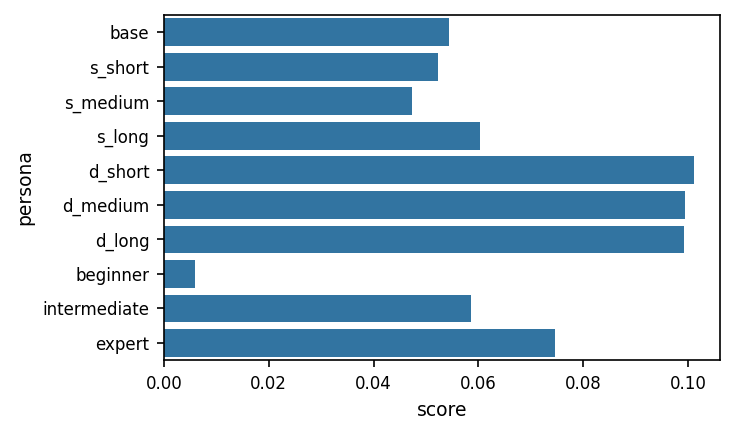

In [101]:
fig, ax = plt.subplots(figsize=(5, 3))
sns.barplot(aggregate_df, orient="h", ax=ax)
plt.tight_layout()
plt.savefig("plots/results/1_0_datasets.png")

- Across all datasets, there seems to be a positive impact of dynamic personas
- Dynamic ones seem better than static
- Longer personas not necessarily better
- Teacher personas follow intuitive trend

## Performance By Dataset

In [91]:
dataset_df = df.copy()
dataset_df = dataset_df[~dataset_df["dataset"].isin(["flores", "alpaca"])]
dataset_df = dataset_df.groupby(["dataset", "persona"], as_index=False)["score"].mean()

parts = []
for dataset_name, group_df in dataset_df.groupby("dataset", sort=False):
    ref = group_df.loc[group_df["persona"] == "helpful", "score"]

    ref_score = ref.iloc[0]
    group_df["reference_score"] = ref_score
    group_df["gain"] = group_df["score"] - ref_score
    parts.append(group_df)

dataset_df: pd.DataFrame = pd.concat(parts, ignore_index=True)
dataset_df = dataset_df.sort_values("persona", key=lambda s: s.map(_order_map))
dataset_df = dataset_df[dataset_df["persona"] != "helpful"]

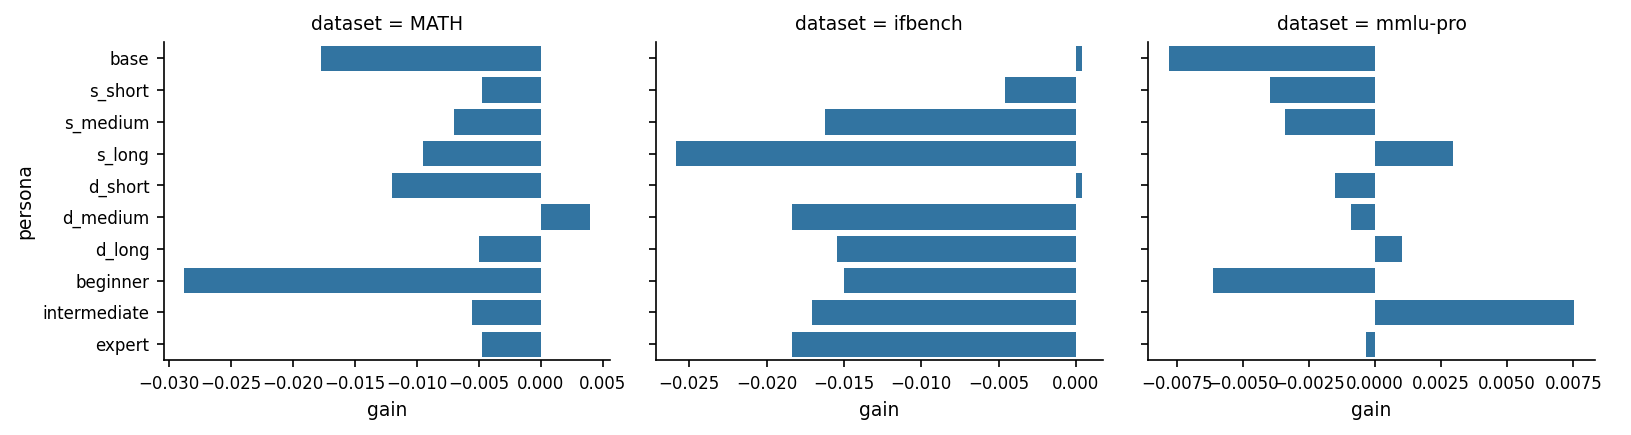

In [92]:
plot_kwargs = {"height": 3, "aspect": 1.2, "width": 0.8}
sns.catplot(dataset_df, col="dataset", y="persona", kind="bar", x="gain", orient="h", sharex=False,
            **plot_kwargs)
plt.savefig("plots/results/1_1_per_dataset.png")

- if we split up the comparison dataset-wise, the outcome changes a bit: it is dataset-dependent
- one some datasets, the impact is more positive: e.g. mmlu-pro and MATH
- on some it seems worse: e.g. ifbench
- there is also some variability in the performance impact per-dataset, e.g. on alpaca, dynami ones have a very large impact, on mmlu-pro not so much

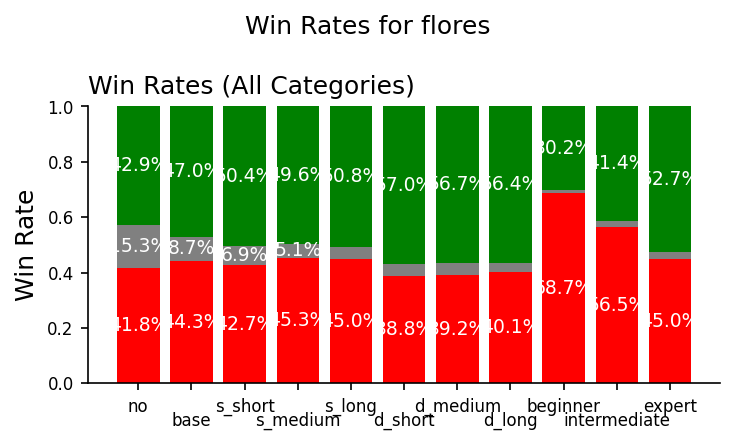

In [93]:
plotting_wrapper.create_overall_stacked_barchart("flores")

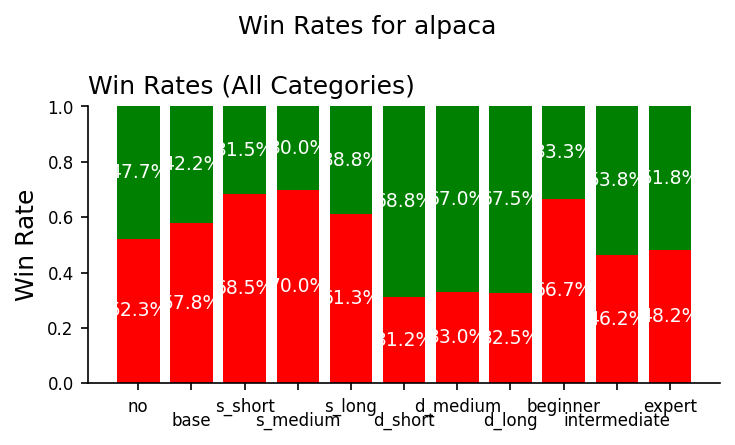

In [94]:
plotting_wrapper.create_overall_stacked_barchart("alpaca")

In [102]:
dataset_results = tests_baseline_df[tests_baseline_df["category"].isna()]
print_sig(dataset_results, "dataset")

 === MATH ===
    === MATH
    Persona beginner_teacher     p-val 0.002 coef -0.160
 === alpaca ===
    === alpaca
    Persona beginner_teacher     p-val 0.000 coef -0.441
    Persona dynamic_long         p-val 0.000 coef 1.033
    Persona dynamic_medium       p-val 0.000 coef 1.008
    Persona dynamic_short        p-val 0.000 coef 1.090
    Persona expert_teacher       p-val 0.000 coef 0.352
    Persona intermediate_teacher p-val 0.000 coef 0.432
    Persona no                   p-val 0.000 coef 0.226
    Persona static_long          p-val 0.000 coef -0.178
    Persona static_medium        p-val 0.000 coef -0.554
    Persona static_short         p-val 0.000 coef -0.482
 === flores ===
    === flores
    Persona beginner_teacher     p-val 0.000 coef -0.899
    Persona dynamic_long         p-val 0.000 coef 0.286
    Persona dynamic_medium       p-val 0.000 coef 0.309
    Persona dynamic_short        p-val 0.000 coef 0.325
    Persona expert_teacher       p-val 0.000 coef 0.109
    Perso

- some datasets benefit more than others (e.g. mmlu-pro)
- ifbench seems completely agnostic to personas
- flores on the other hand seems very good

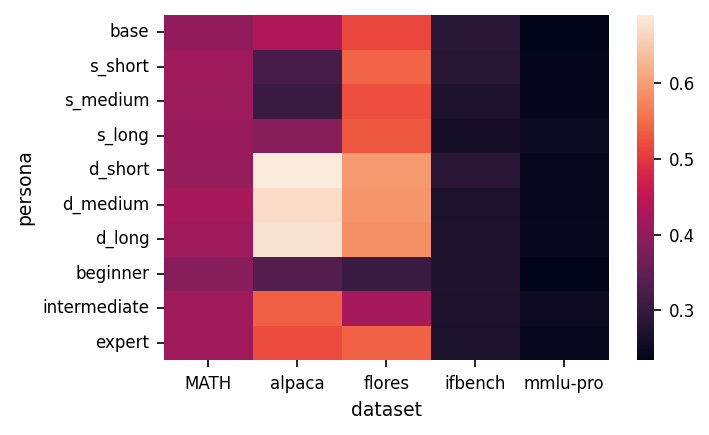

In [69]:
pivot_df = df.groupby(["dataset", "persona"], as_index=False)["score"].mean()
pivot_df = pivot_df.pivot(index="persona", columns="dataset", values="score")
pivot_df = pivot_df.reindex(_order_map.keys())

fig, ax = plt.subplots(figsize=(5, 3))
sns.heatmap(data=pivot_df)
plt.tight_layout()
plt.savefig("plots/results/1_0_datasets_heatmap.png")

## Performance By Dataset Subcategory

In [103]:
category_df = df.copy()
category_df = category_df.groupby(["dataset", "model", "category", "persona"], as_index=False)["score"].mean()

parts = []
for dataset_name, group_df in category_df.groupby(["category", "model"], sort=False):
    if "helpful" in group_df["persona"].unique():
        ref = group_df.loc[group_df["persona"] == "helpful", "score"]

        ref_score = ref.iloc[0]
        group_df["reference_score"] = ref_score
        group_df["gain"] = group_df["score"] - ref_score
    else:
        group_df["gain"] = group_df["score"]
    parts.append(group_df)

category_df: pd.DataFrame = pd.concat(parts, ignore_index=True)
category_df = category_df.sort_values("persona", key=lambda s: s.map(_order_map))
category_df = category_df[category_df["persona"] != "helpful"]

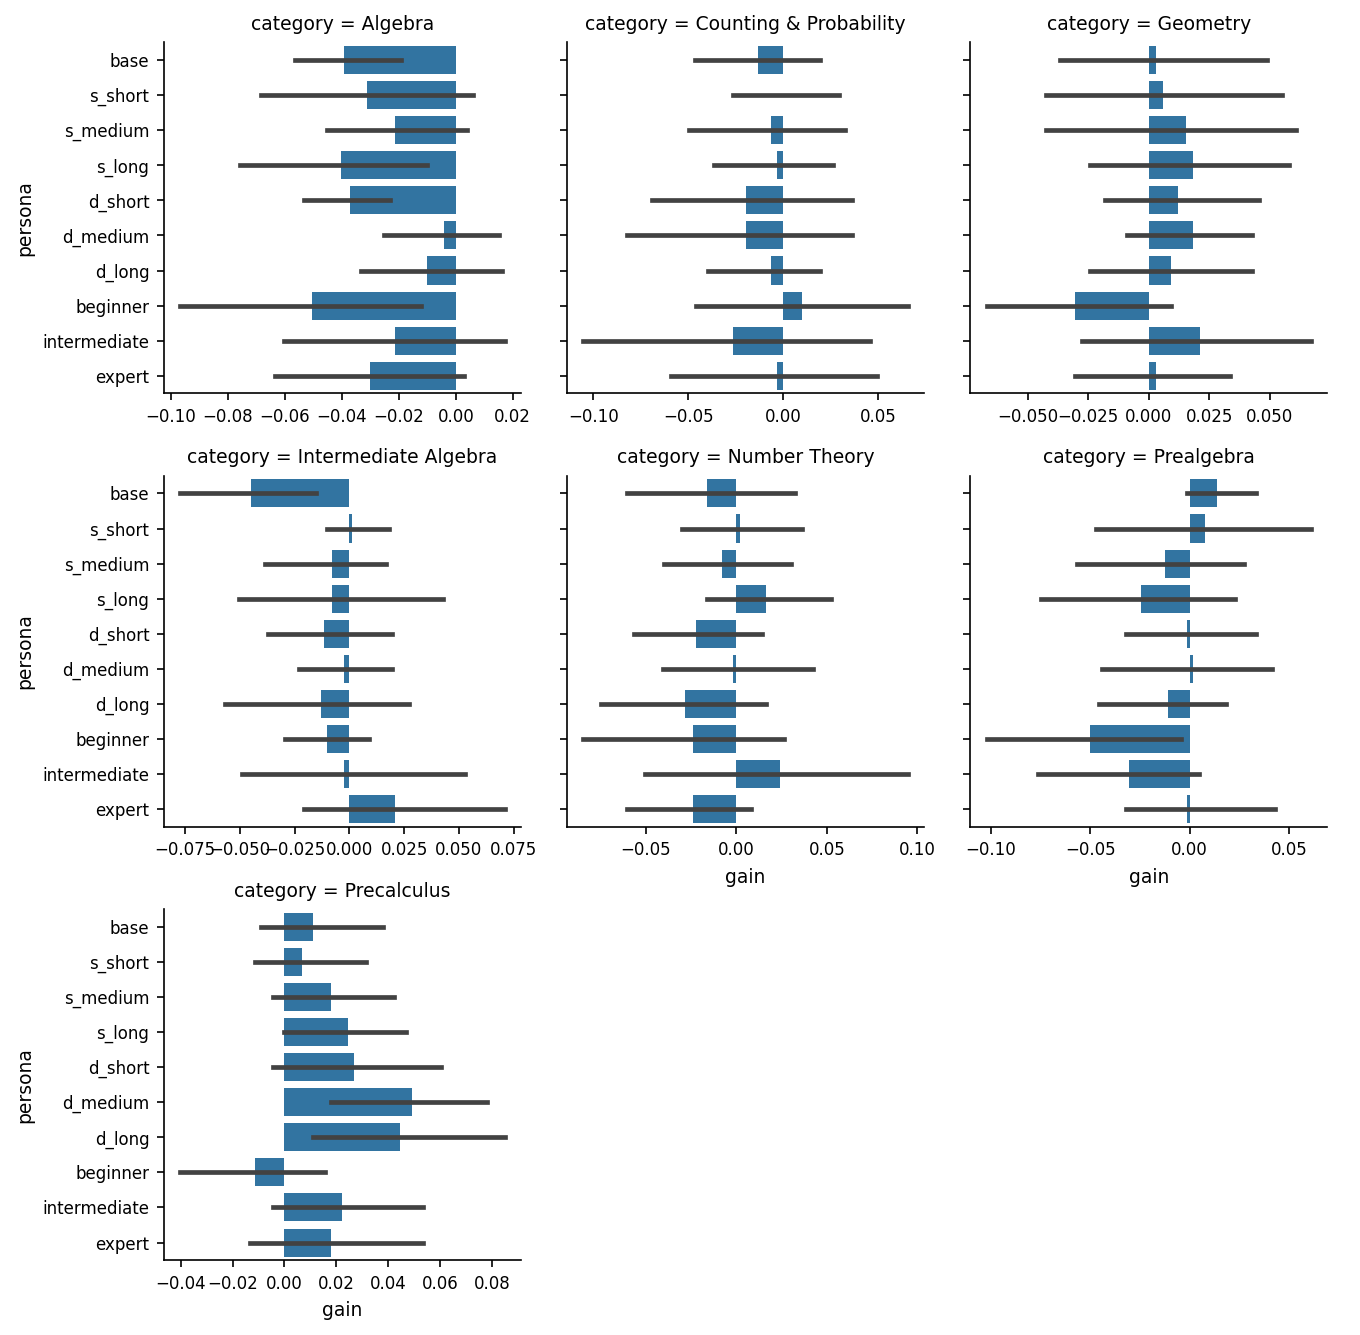

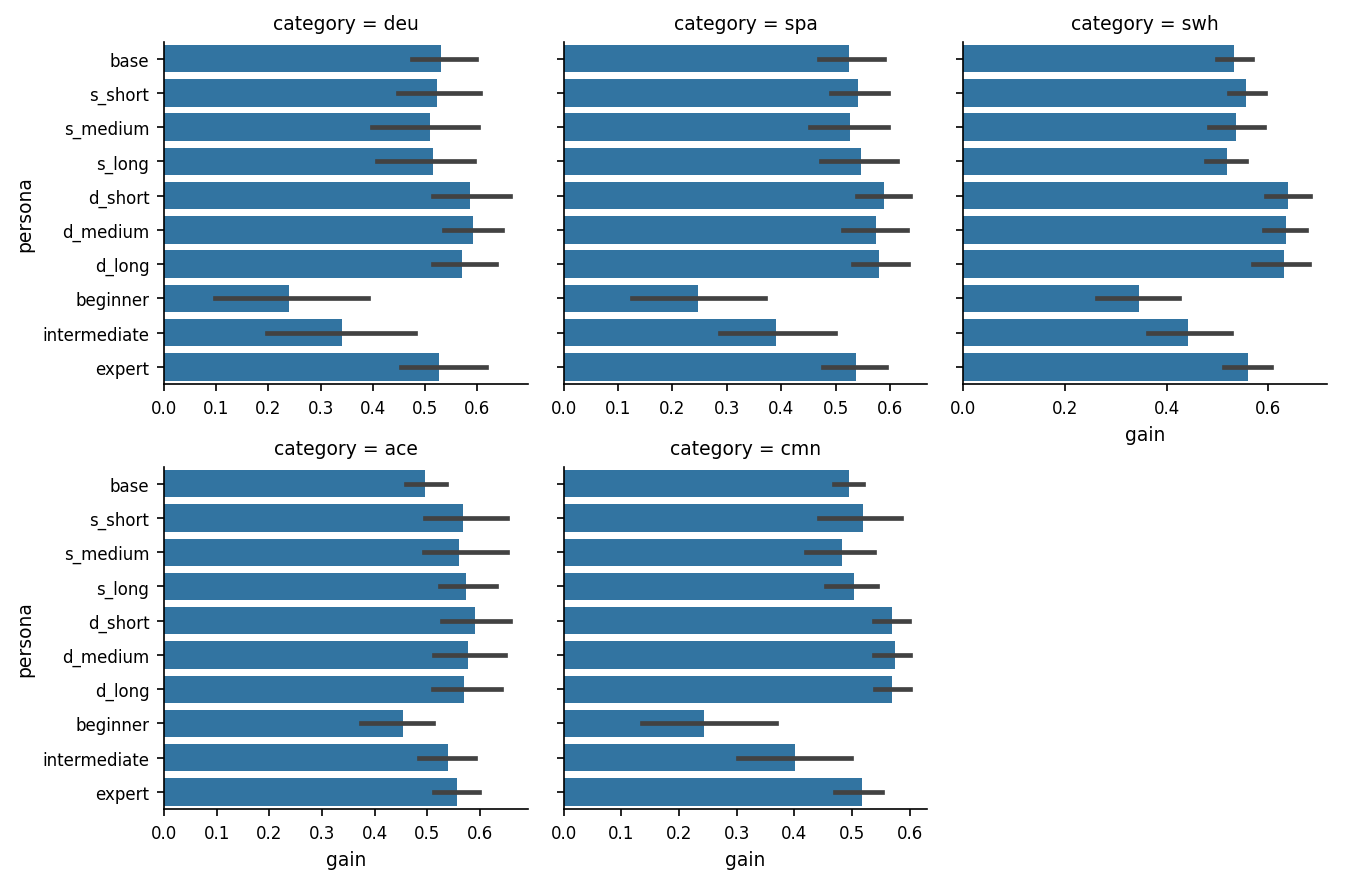

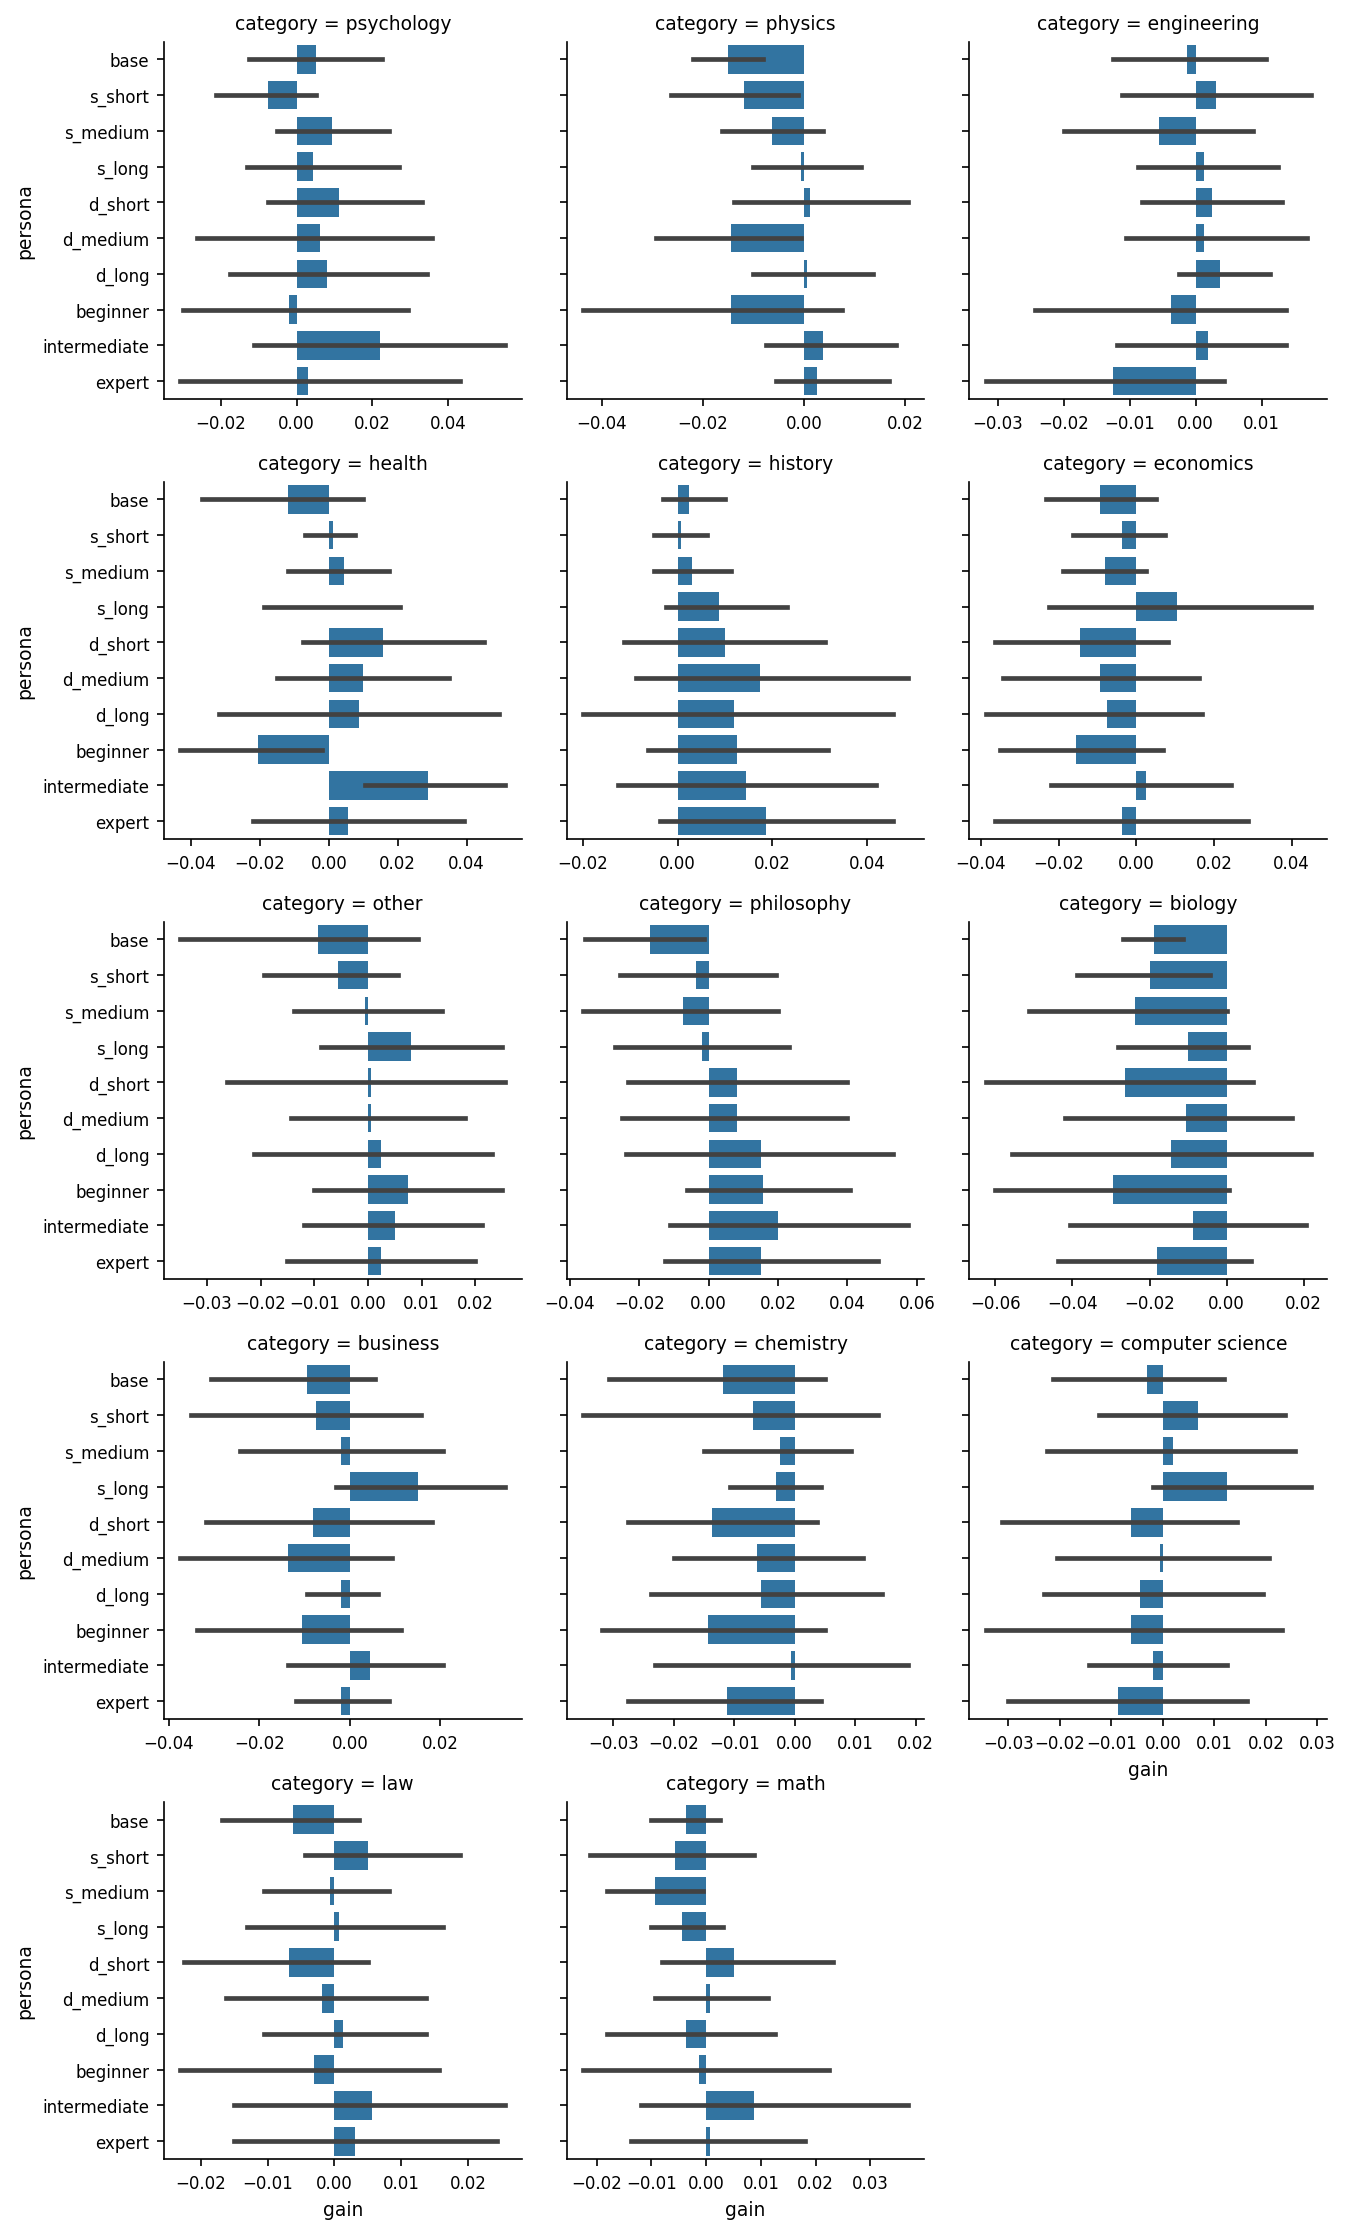

In [104]:
for dataset, sub_df in category_df.groupby("dataset"):
    sns.catplot(sub_df, col="category", y="persona", kind="bar", x="gain", orient="h", sharex=False, height=3, col_wrap=3)

- similar to datasets as a whole, the impact of personas also depends on subcategories

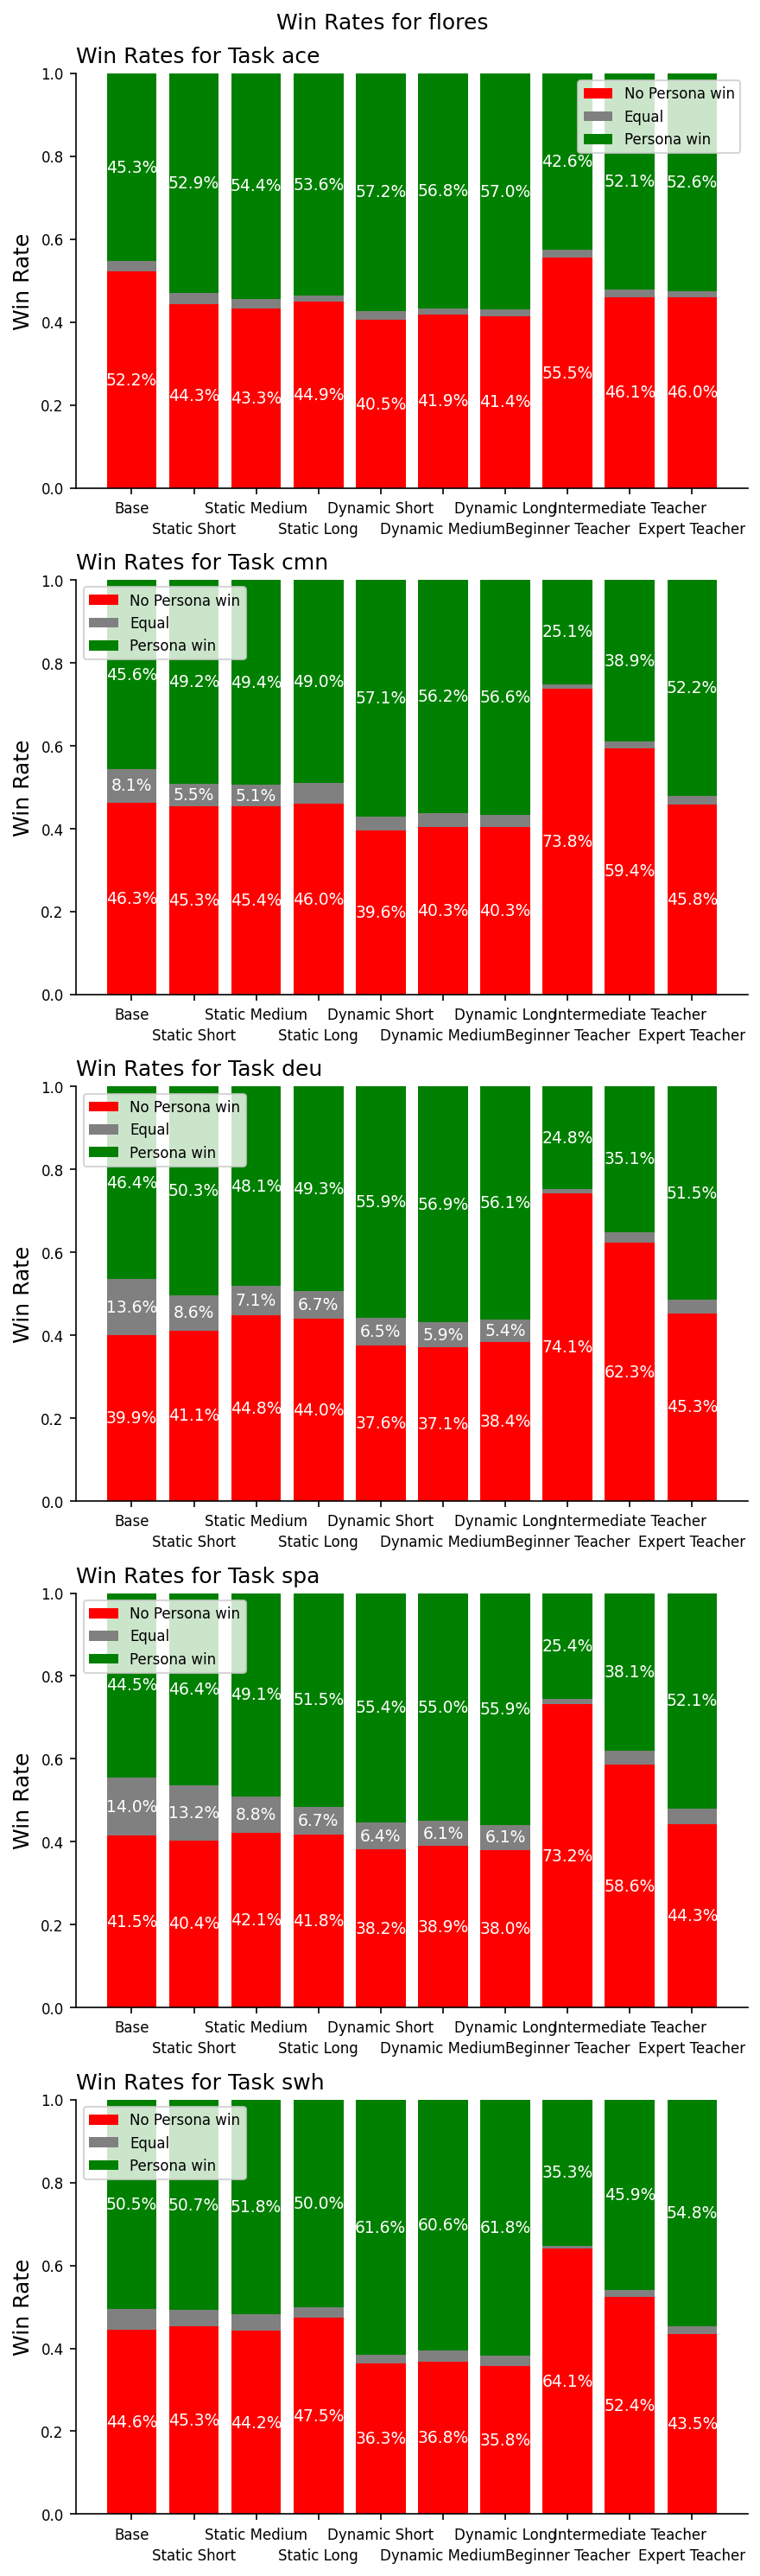

In [25]:
plotting_wrapper.create_stacked_barchart_plots("flores", "iso_639_3")

In [105]:
print_sig(tests_baseline_df, "category")

 === MATH ===
    === Algebra
    Persona base                 p-val 0.038 coef -0.221
    Persona beginner_teacher     p-val 0.008 coef -0.284
    Persona dynamic_short        p-val 0.049 coef -0.210
    Persona static_long          p-val 0.033 coef -0.227
    === Counting & Probability
    === Geometry
    === Intermediate Algebra
    Persona base                 p-val 0.013 coef -0.350
    === Number Theory
    === Prealgebra
    Persona beginner_teacher     p-val 0.046 coef -0.241
    === Precalculus
 === alpaca ===
 === flores ===
    === ace
    Persona beginner_teacher     p-val 0.014 coef -0.174
    Persona dynamic_long         p-val 0.000 coef 0.302
    Persona dynamic_medium       p-val 0.000 coef 0.325
    Persona dynamic_short        p-val 0.000 coef 0.384
    Persona expert_teacher       p-val 0.000 coef 0.247
    Persona intermediate_teacher p-val 0.016 coef 0.170
    Persona static_long          p-val 0.000 coef 0.319
    Persona static_medium        p-val 0.000 coef 0.2

- outcome also quite sensitive to categorize
- dynamic persona even stronger than before
- teachers follow mostly positive trend
- but partially, results are not significant anymore


# 2. Comparison by length

In [12]:
from evaluate import prepare_length

dfs = []
for mode in ["static", "dynamic", "combined"]:
    mode: Literal["static", "dynamic", "combined"] = mode   # to silence warning
    length_df = prepare_length(length_base_df, mode)
    length_df["mode"] = mode
    dfs.append(length_df)
length_df: pd.DataFrame = pd.concat(dfs)

length_mapping = {1: "base", 2: "short", 3: "medium", 4: "long"}
length_df["length"] = length_df["length"].map(length_mapping)
length_df["length"] = pd.Categorical(length_df["length"], categories=length_mapping.values(), ordered=True)

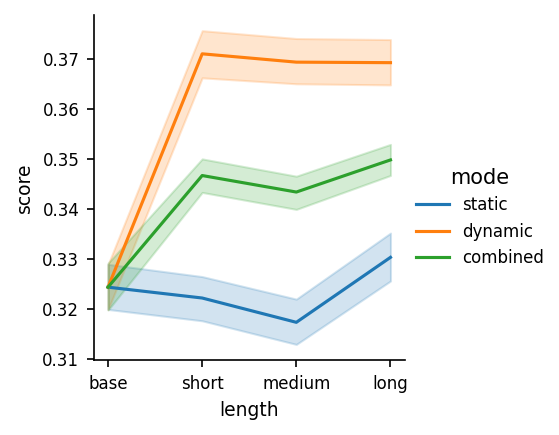

In [13]:
facet_kw = {"sharey": "row"}
sns.relplot(length_df, x="length", y="score", hue="mode", kind="line", height=3, facet_kws=facet_kw)
plt.savefig("plots/results/2_0_datasets.png")

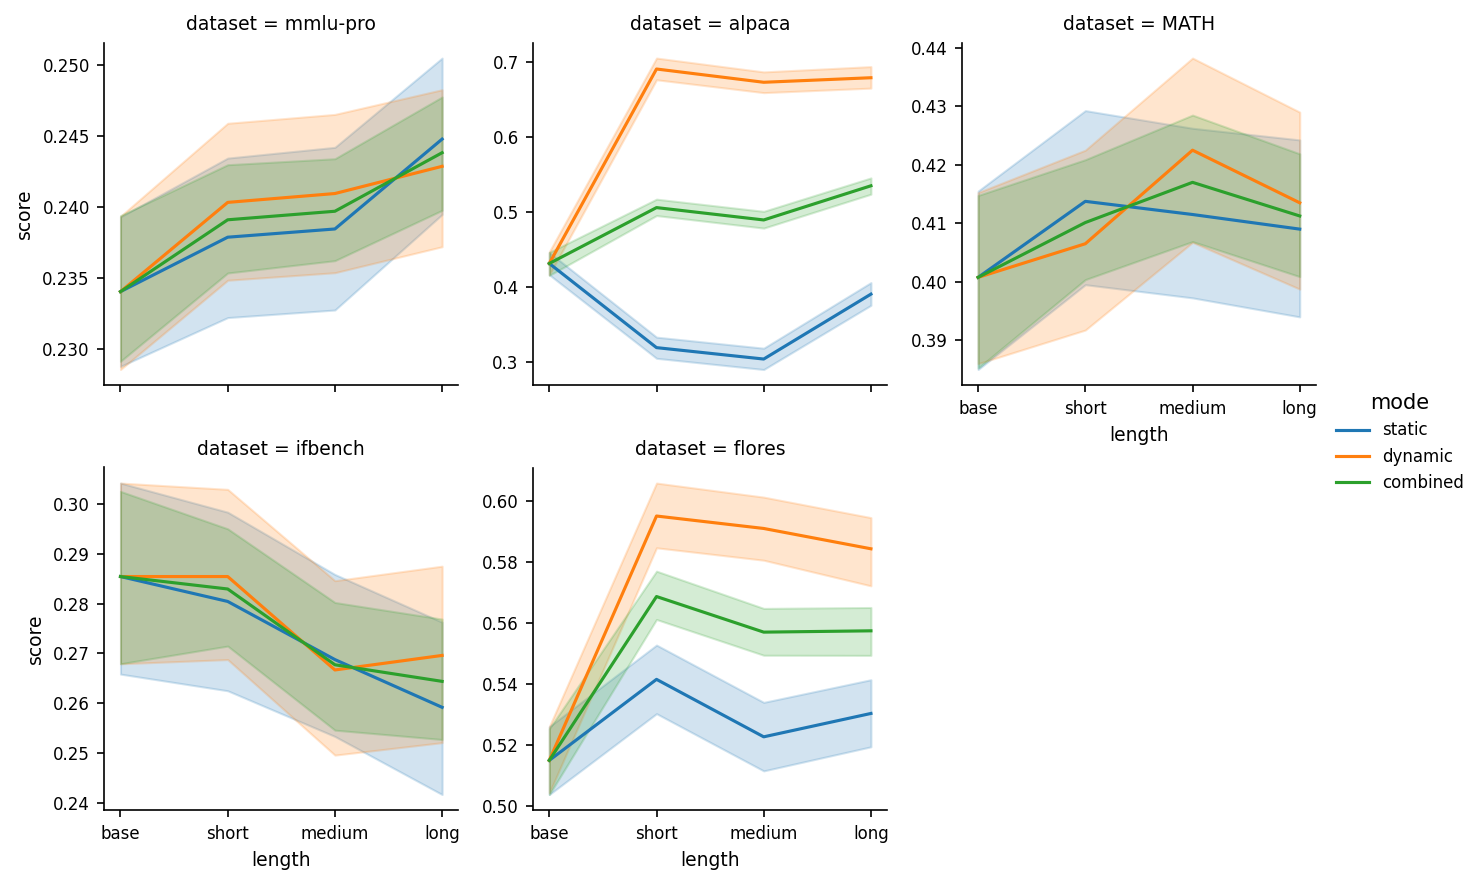

In [14]:
facet_kw = {"sharey": False}
sns.relplot(length_df, x="length", y="score", col="dataset", hue="mode", kind="line", facet_kws=facet_kw, height=3, col_wrap=3)
plt.savefig("plots/results/2_1_per_dataset")

In [15]:
dataset_len_results = tests_length_df[tests_length_df["category"].isna()]
print_sig(dataset_len_results, "dataset")

 === MATH ===
    === MATH
 === alpaca ===
    === alpaca
 === flores ===
    === flores
 === ifbench ===
    === ifbench
 === mmlu-pro ===
    === mmlu-pro


- ifbench showed mostly negative trends before, so it is expected that the length will also have a negative impact
- MATH and mmlu-pro seem most intuitive, though mmlu-pro does not have a statistically significant impact
- very little strictly monotonic cases

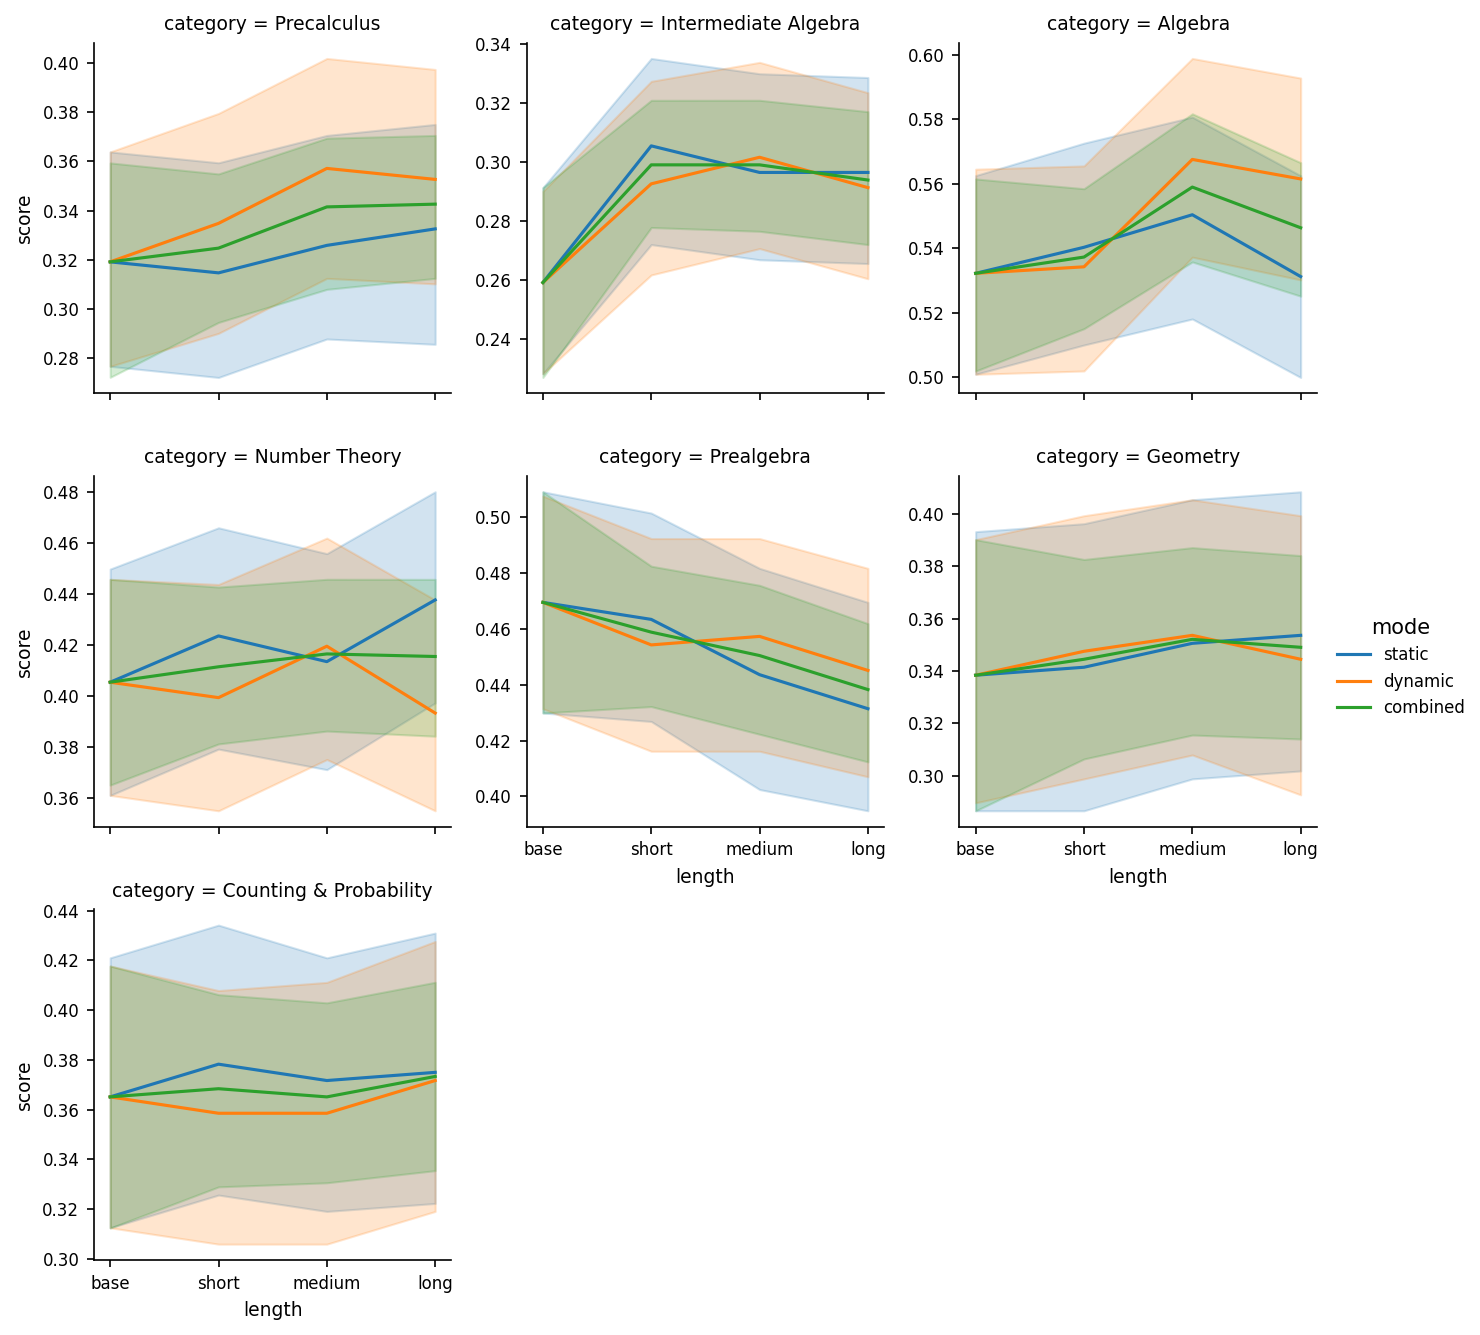

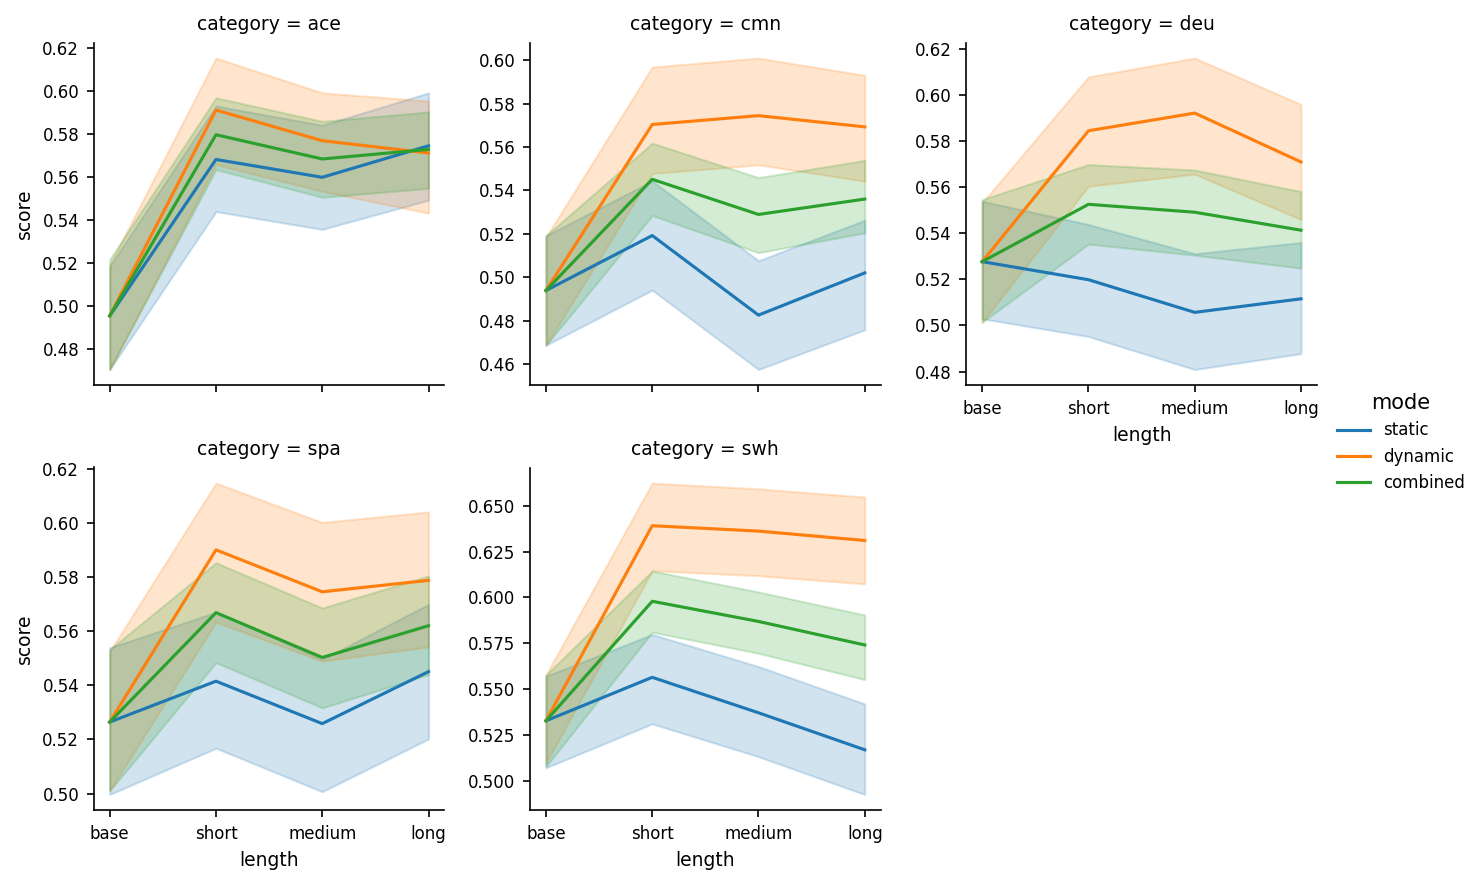

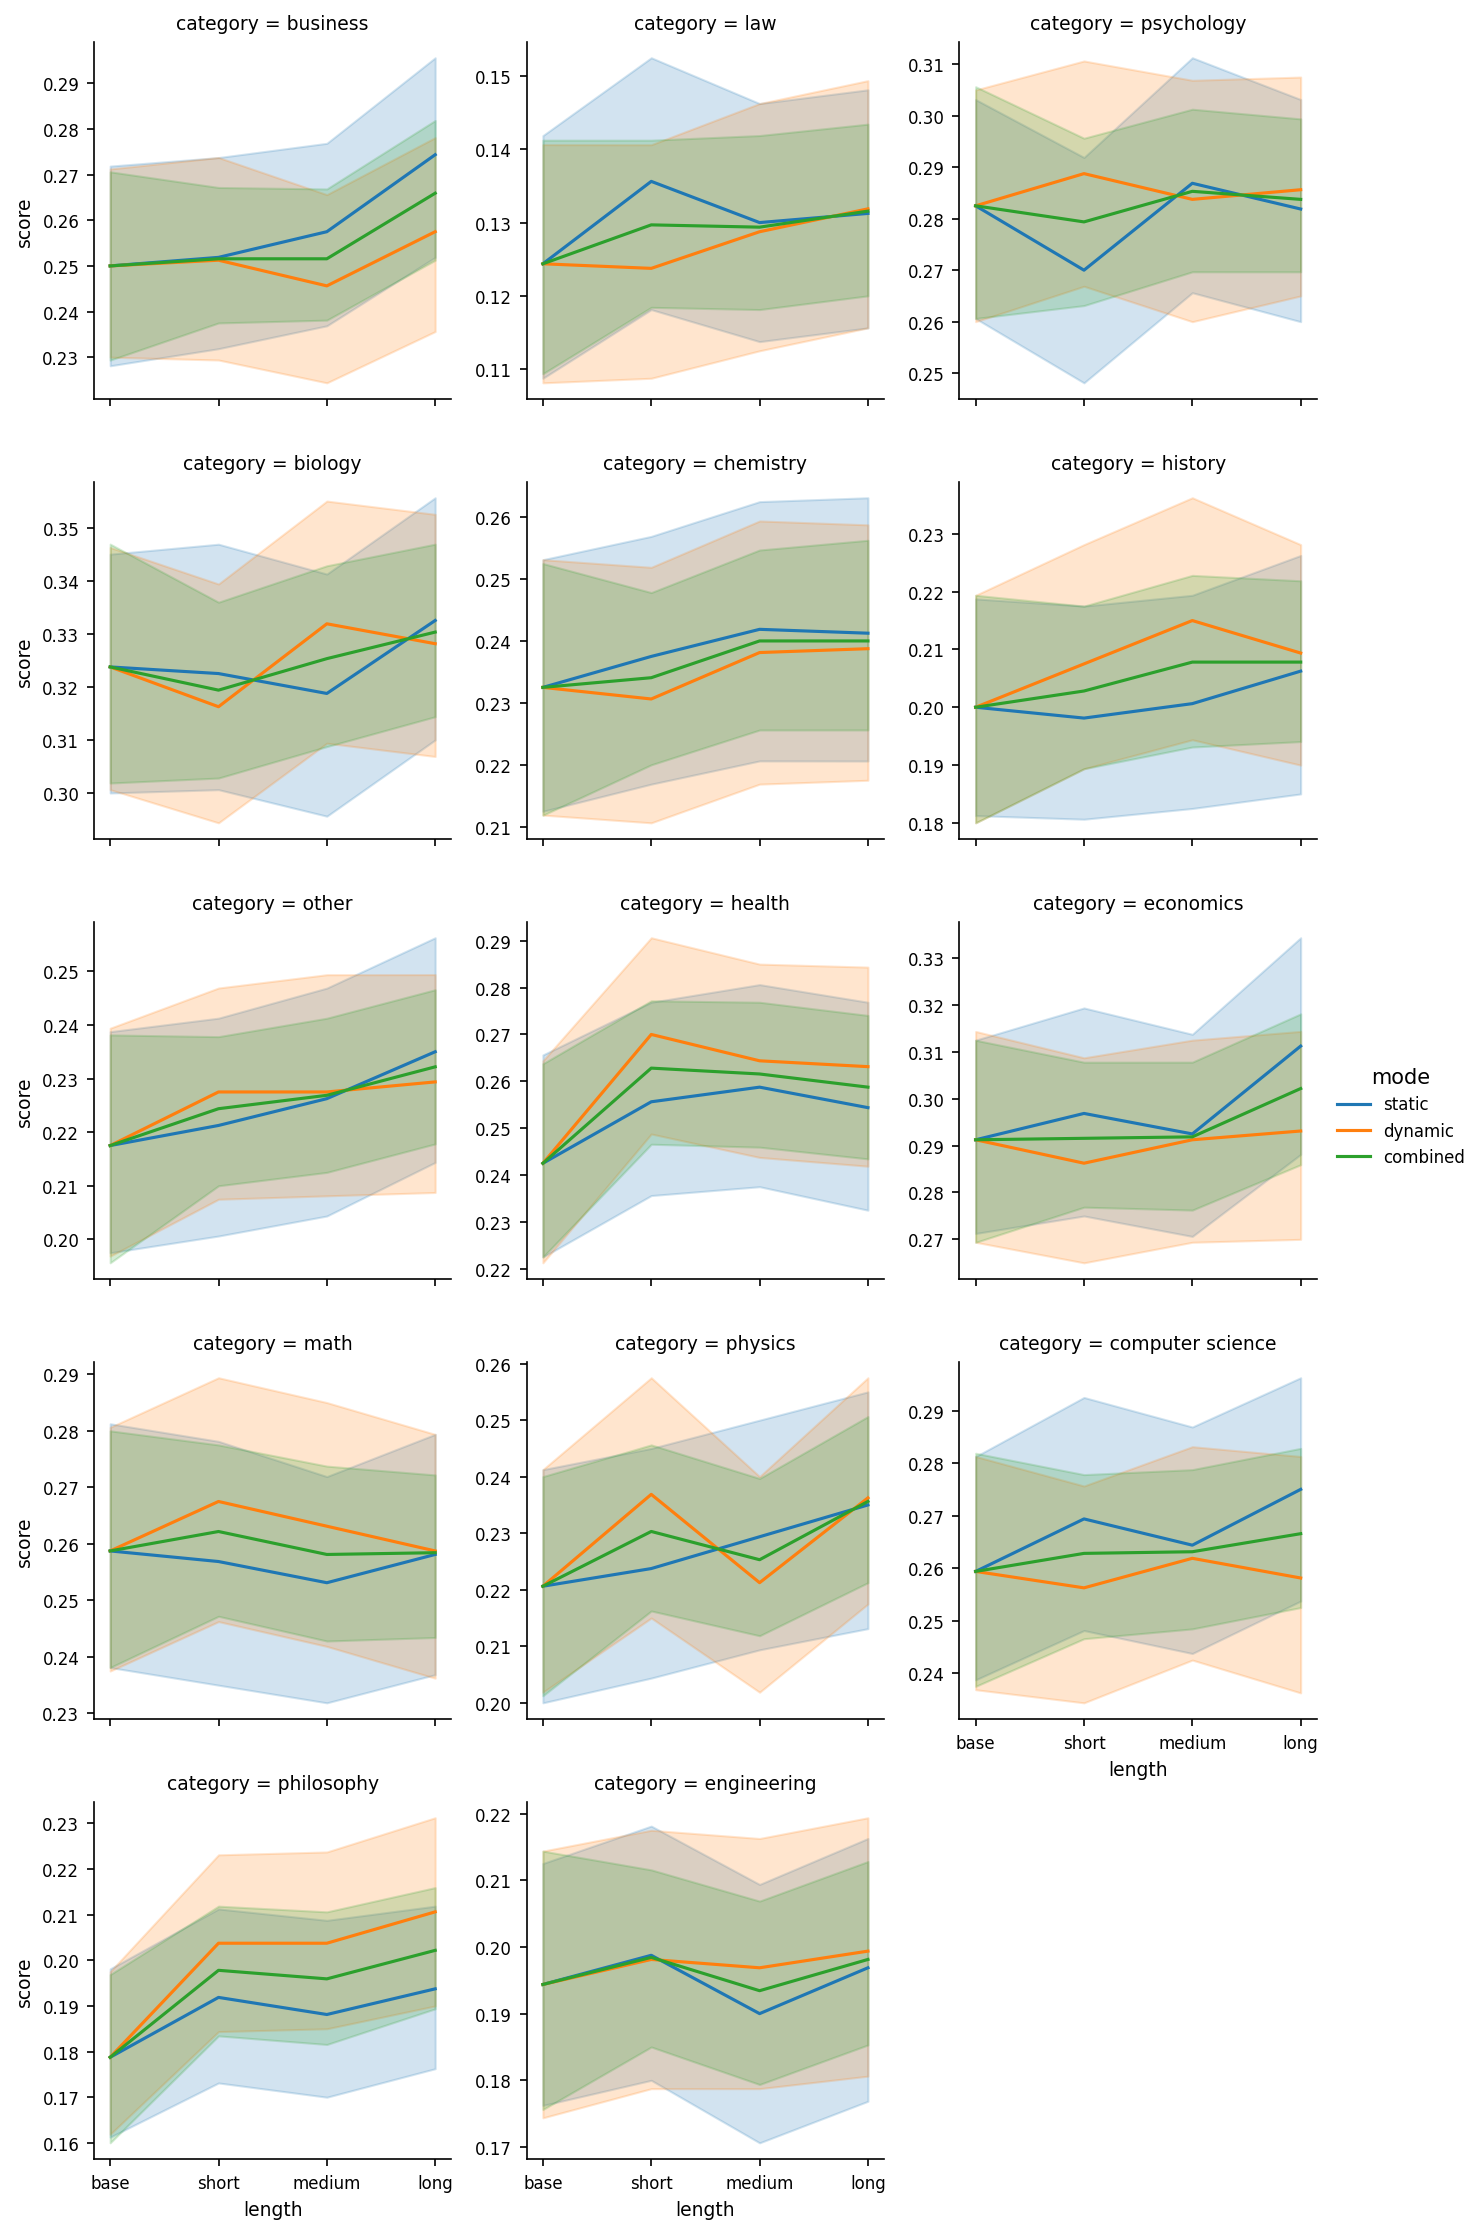

In [35]:
facet_kw = {"sharey": False}
d_cat_df = length_df.dropna()
for dataset, group_df in d_cat_df.groupby("dataset"):
    sns.relplot(group_df, x="length", y="score", hue="mode", col="category", kind="line", facet_kws=facet_kw, height=3, col_wrap=3)

In [36]:
print_sig(tests_length_df, "category")

 === MATH ===
    === Algebra
    Persona length               p-val 0.046 coef 0.066
dynamic
    === Counting & Probability
    === Geometry
    === Intermediate Algebra
    === Number Theory
    === Prealgebra
    === Precalculus
 === alpaca ===
 === flores ===
    === ace
    Persona length               p-val 0.000 coef 0.094
static
    Persona length               p-val 0.000 coef 0.087
dynamic
    Persona length               p-val 0.000 coef 0.067
combined
    === cmn
    Persona length               p-val 0.000 coef 0.095
dynamic
    === deu
    Persona length               p-val 0.002 coef 0.067
dynamic
    === spa
    Persona length               p-val 0.004 coef 0.063
dynamic
    === swh
    Persona length               p-val 0.000 coef 0.127
dynamic
 === ifbench ===
 === mmlu-pro ===
    === biology
    === business
    Persona length               p-val 0.042 coef 0.066
static
    === chemistry
    === computer science
    === economics
    === engineering
    === health
 

- only clear trend observable is that dynamic personas seem very strong on flores+
- also: it seems like the medium length persona is always quite bad, while longer and shorter ones are better

# 3. Comparison by expertise

In [112]:
from evaluate import prepare_teacher

teacher_df = prepare_teacher(length_base_df)
teacher_mapping = {0: "beginner", 1: "intermediate", 2: "expert"}
teacher_df["level"] = teacher_df["level"].map(teacher_mapping)
teacher_df["level"] = pd.Categorical(teacher_df["level"], categories=["beginner", "intermediate", "expert"], ordered=True)

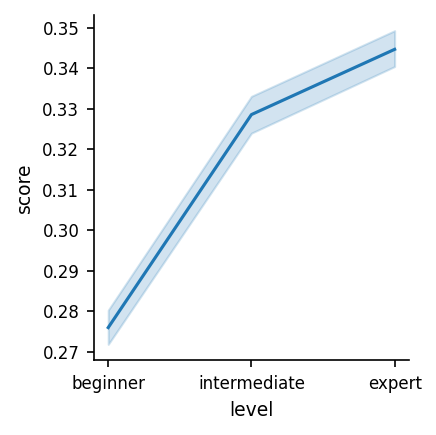

In [113]:
facet_kw = {"sharey": False}
sns.relplot(teacher_df, x="level", y="score", kind="line", facet_kws=facet_kw, height=3)
plt.savefig("plots/results/3_0_datasets.png")

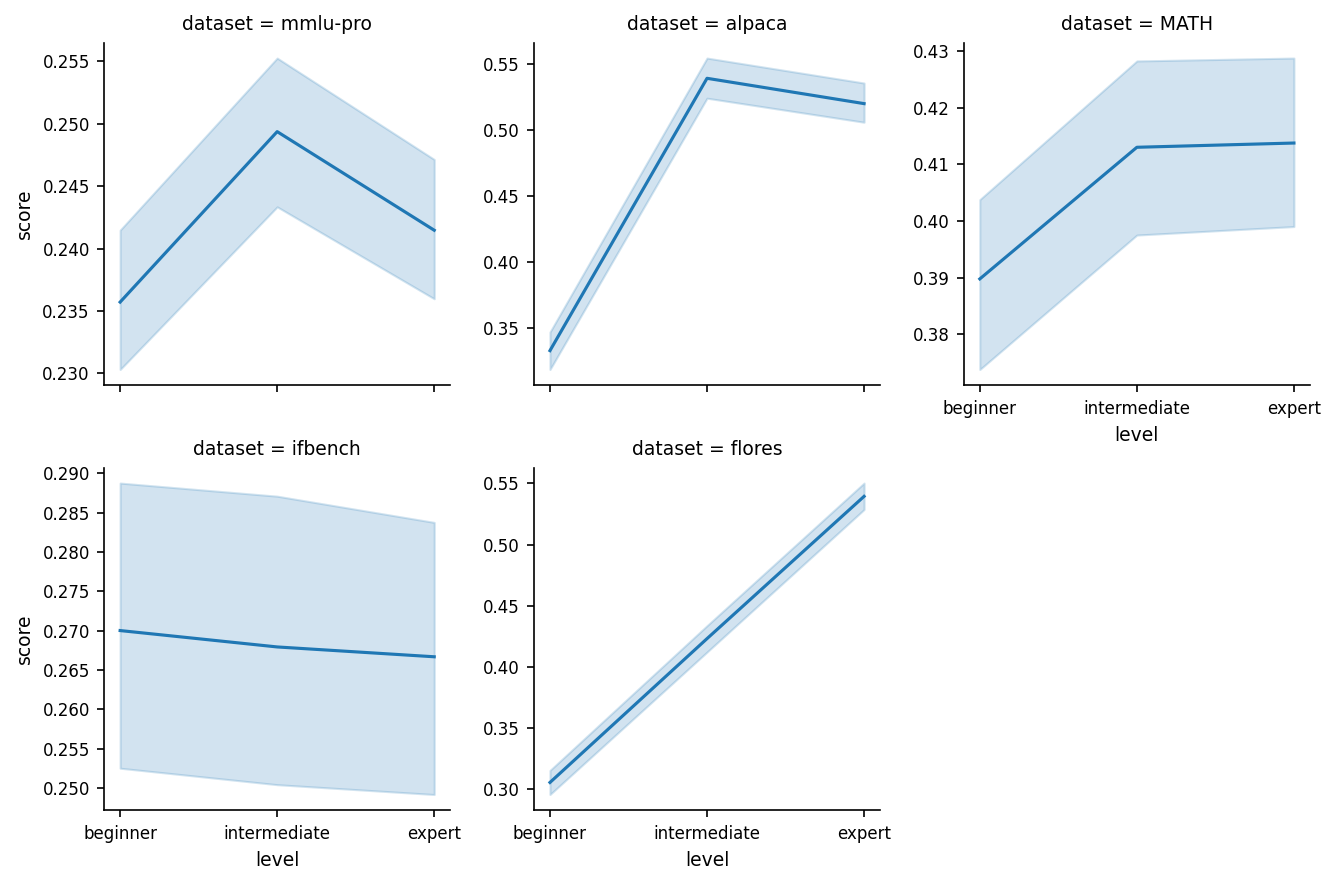

In [114]:
facet_kw = {"sharey": False}
sns.relplot(teacher_df, x="level", y="score", col="dataset", kind="line", col_wrap=3, facet_kws=facet_kw, height=3)
plt.savefig("plots/results/3_1_per_dataset.png")

In [115]:
dataset_teacher_results = tests_teacher_df[tests_teacher_df["category"].isna()]
print_sig(dataset_teacher_results, "dataset")

 === MATH ===
    === MATH
    Persona level                p-val 0.011 coef 0.068
 === alpaca ===
    === alpaca
    Persona level                p-val 0.000 coef 0.407
 === flores ===
    === flores
    Persona level                p-val 0.000 coef 0.504
 === ifbench ===
    === ifbench
 === mmlu-pro ===
    === mmlu-pro


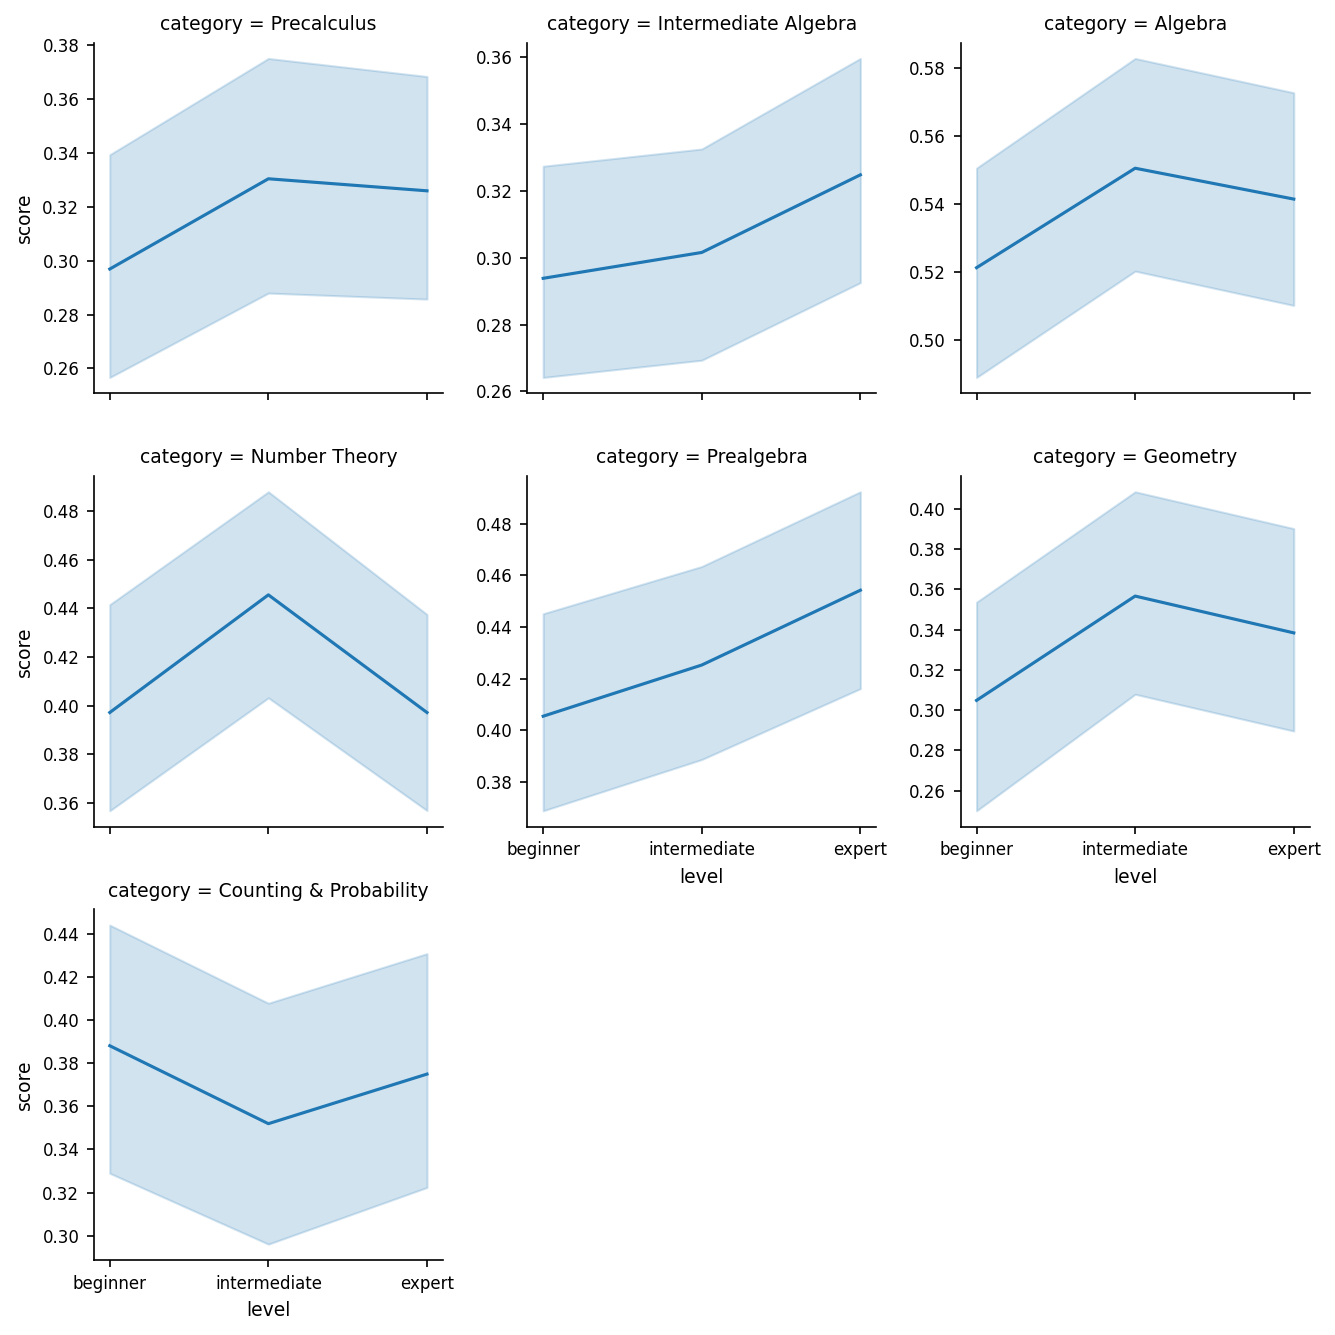

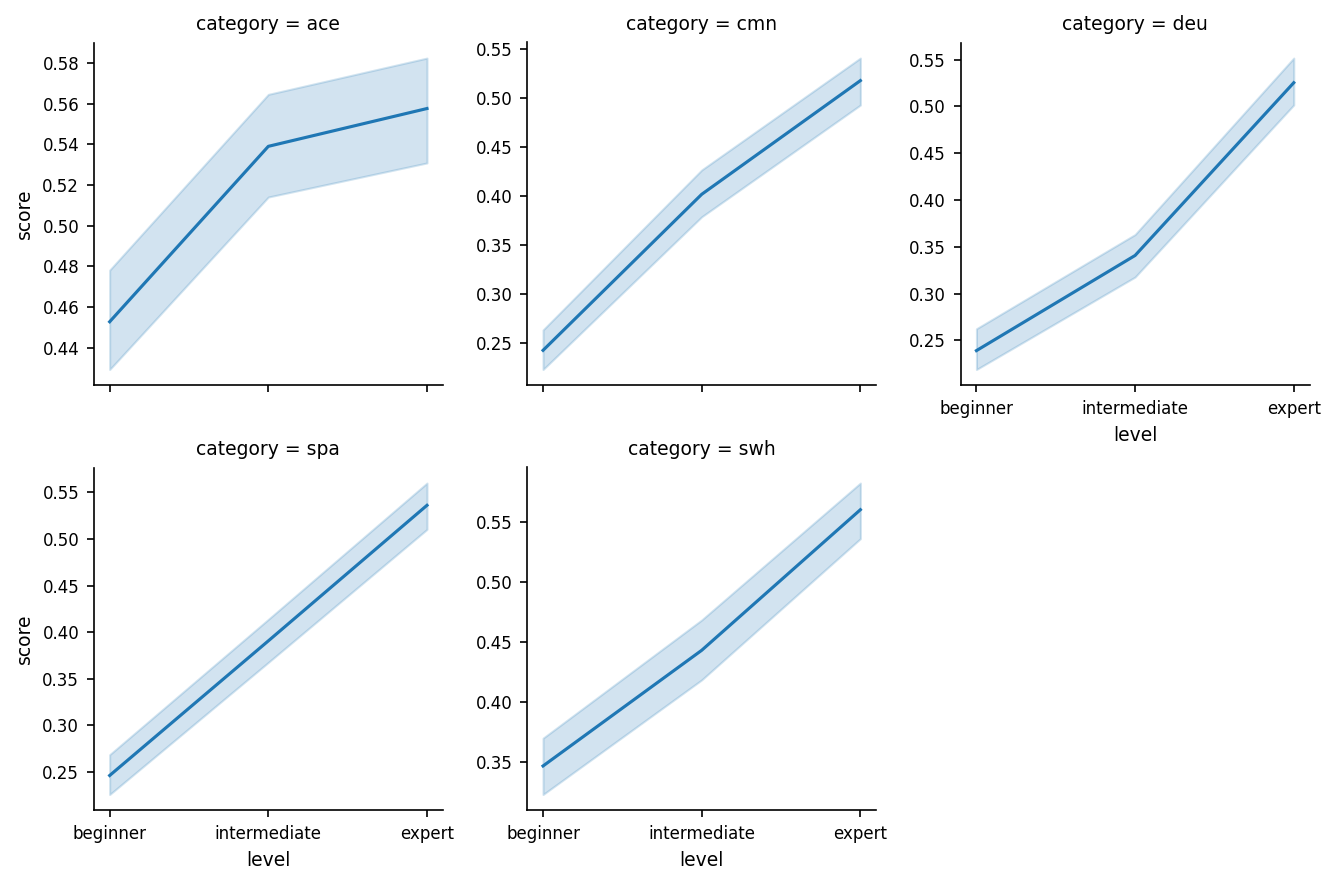

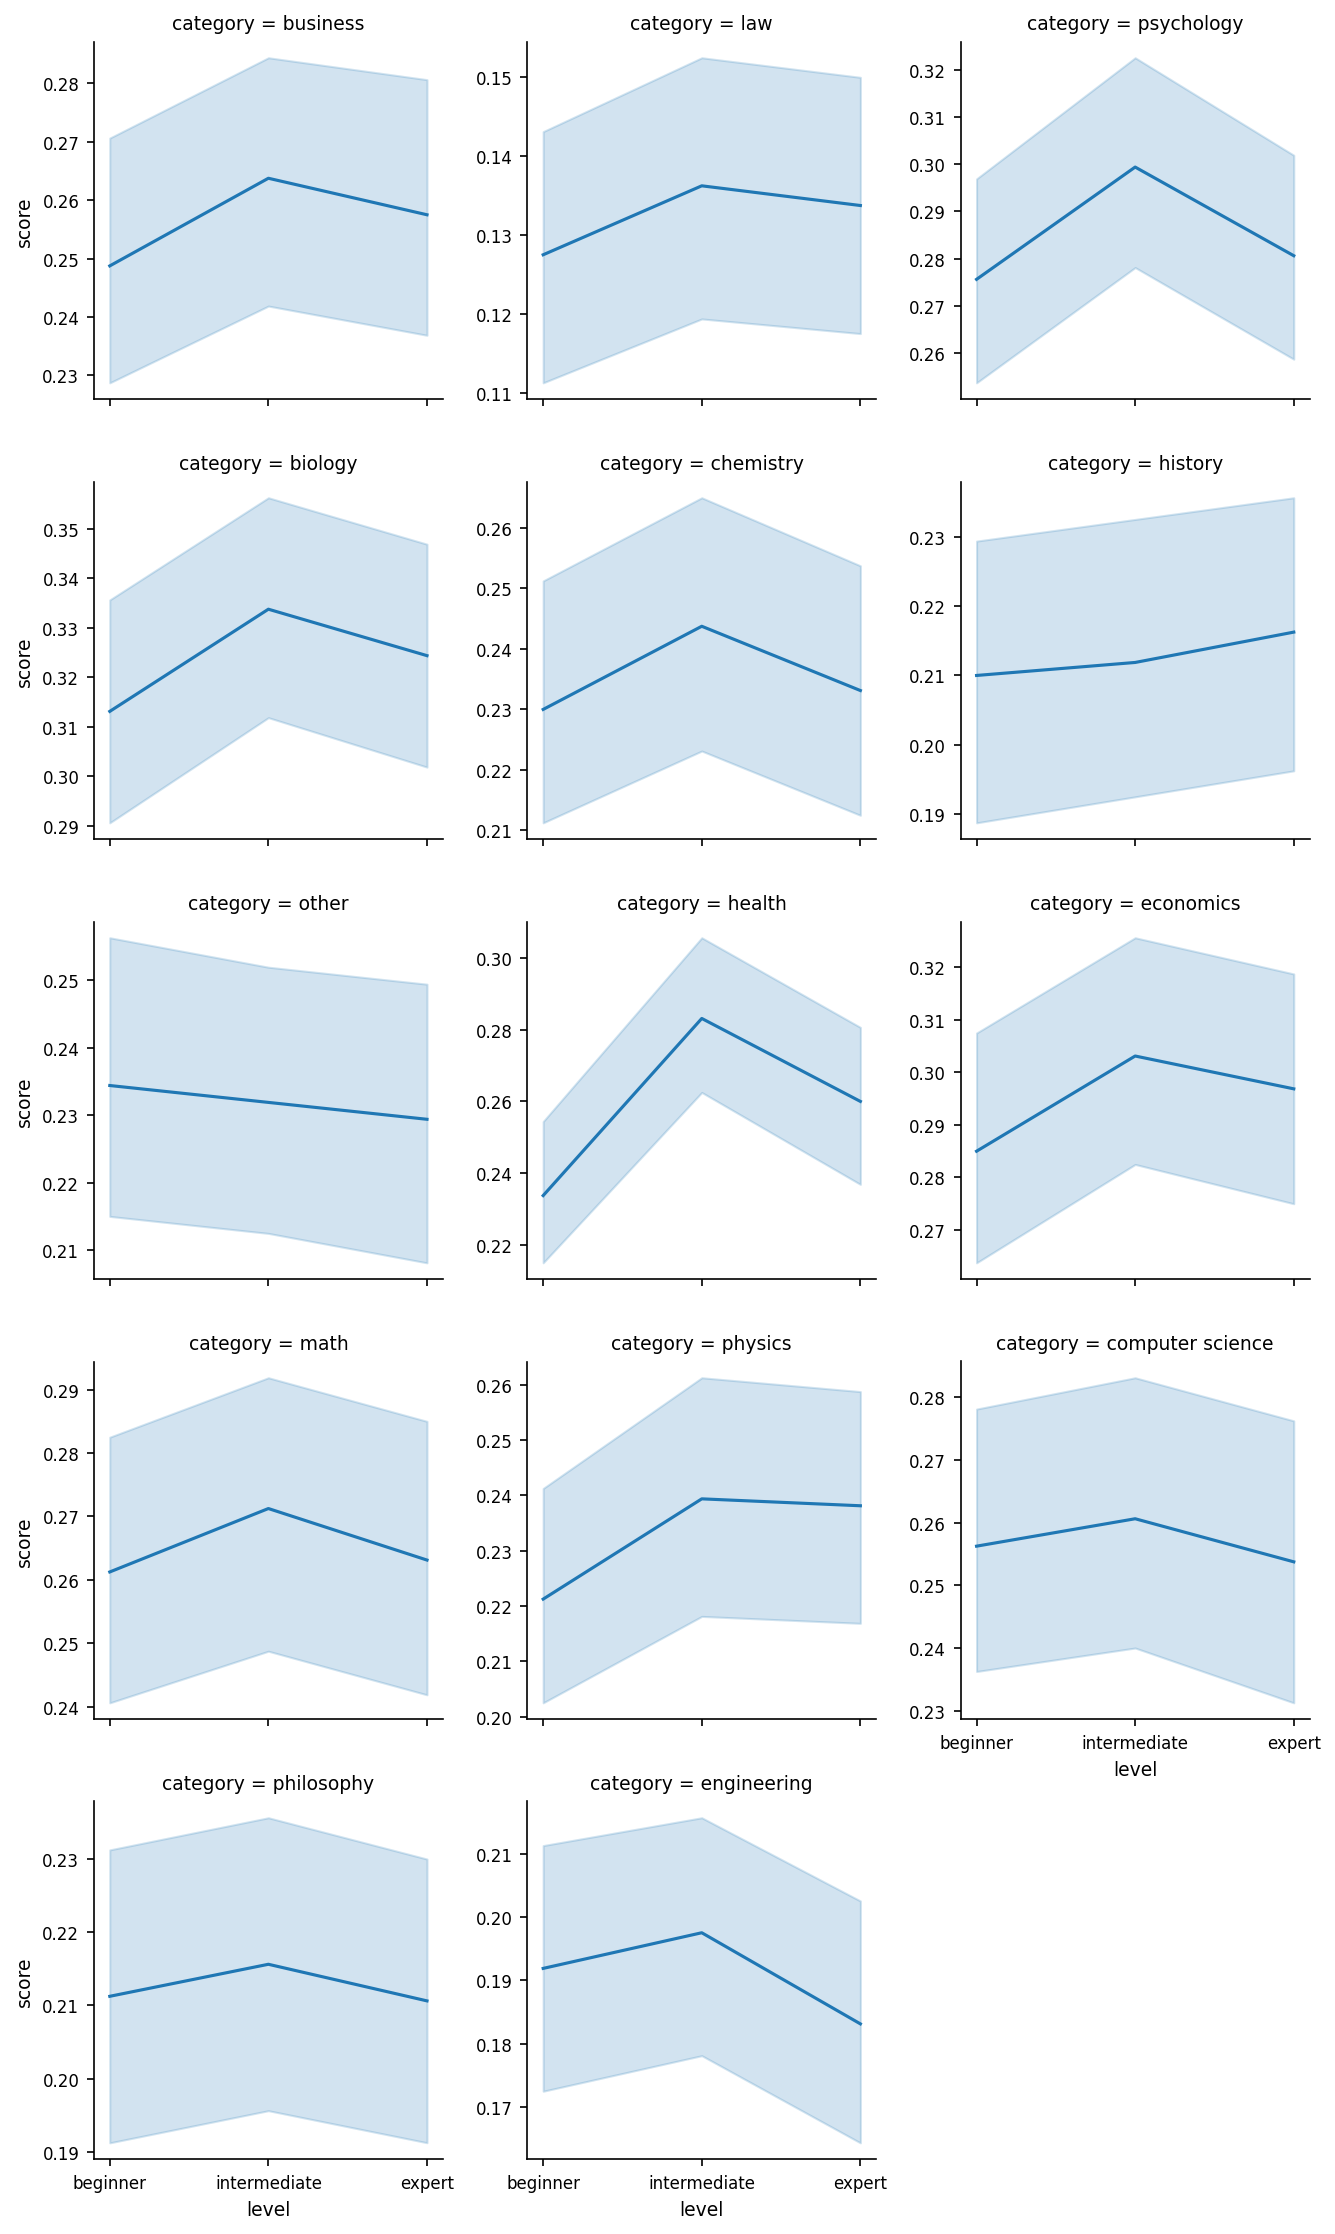

In [116]:
facet_kw = {"sharey": False}
t_cat_df = teacher_df.dropna()
for dataset, group_df in t_cat_df.groupby("dataset"):
    sns.relplot(group_df, x="level", y="score", col="category", kind="line", facet_kws=facet_kw, height=3, col_wrap=3)

In [117]:
print_sig(tests_teacher_df, "category")

 === MATH ===
    === Algebra
    === Counting & Probability
    === Geometry
    === Intermediate Algebra
    === Number Theory
    === Prealgebra
    === Precalculus
 === alpaca ===
 === flores ===
    === ace
    Persona level                p-val 0.000 coef 0.210
    === cmn
    Persona level                p-val 0.000 coef 0.627
    === deu
    Persona level                p-val 0.000 coef 0.725
    === spa
    Persona level                p-val 0.000 coef 0.657
    === swh
    Persona level                p-val 0.000 coef 0.454
 === ifbench ===
 === mmlu-pro ===
    === biology
    === business
    === chemistry
    === computer science
    === economics
    === engineering
    === health
    Persona level                p-val 0.044 coef 0.097
    === history
    === law
    === math
    === other
    === philosophy
    === physics
    === psychology


# 4. Static vs. Dynamic

In [24]:
from evaluate import prepare_static_vs_dynamic

dynamic_df = prepare_static_vs_dynamic(length_base_df)
dynamic_df.reset_index(inplace=True)

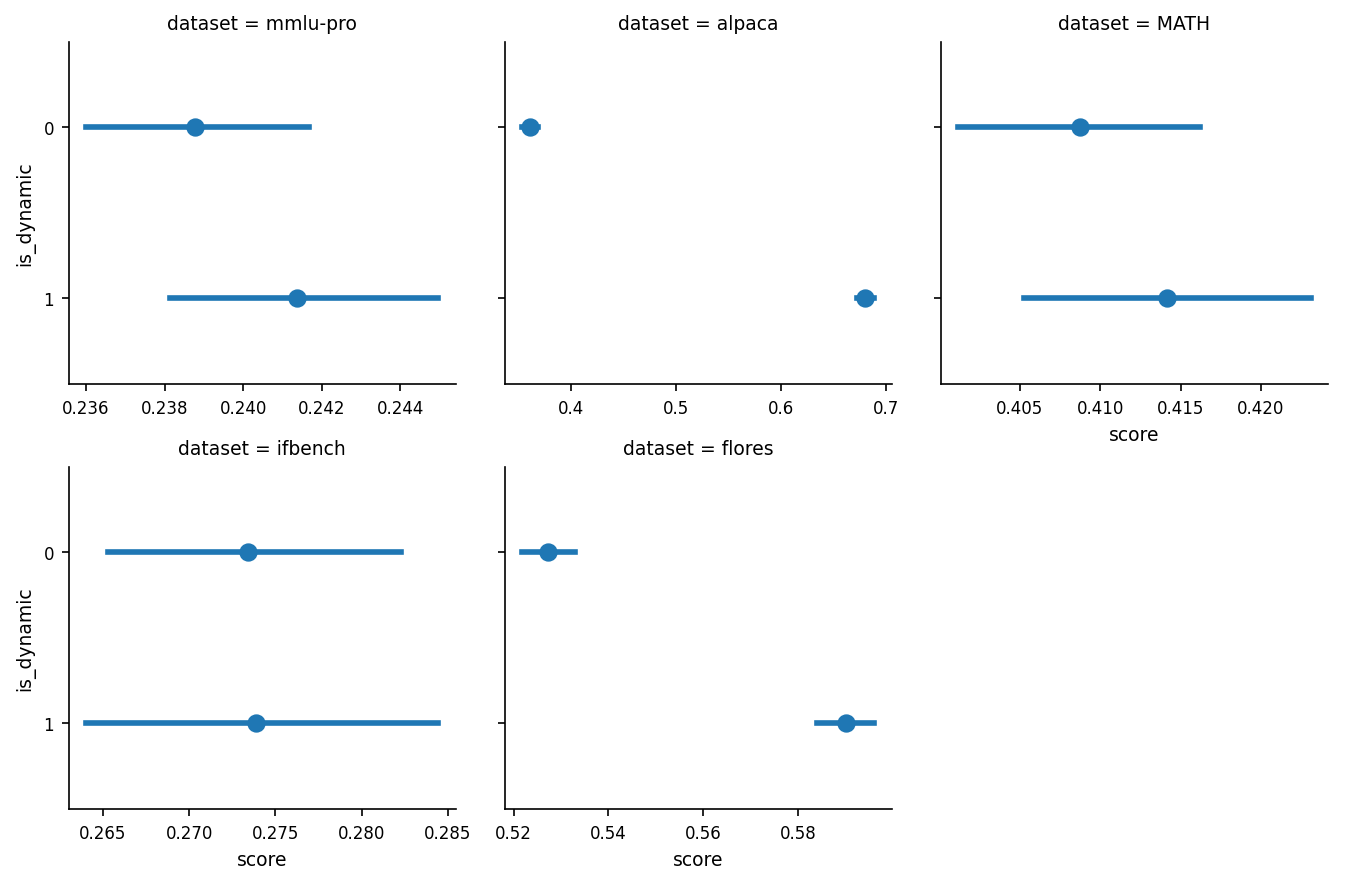

In [25]:
sns.catplot(dynamic_df, col="dataset", x="score", y="is_dynamic", kind="point", orient="h", col_wrap=3, sharex=False, height=3, linestyle="none")
plt.savefig("plots/results/4_0_datasets.png")

In [27]:
dataset_dynamic_results = tests_dynamic_df[tests_dynamic_df["category"].isna()]
print_sig(dataset_dynamic_results, "dataset")

 === MATH ===
    === MATH
 === alpaca ===
    === alpaca
    Persona is_dynamic           p-val 0.000 coef 1.336
 === flores ===
    === flores
    Persona is_dynamic           p-val 0.000 coef 0.255
 === ifbench ===
    === ifbench
 === mmlu-pro ===
    === mmlu-pro


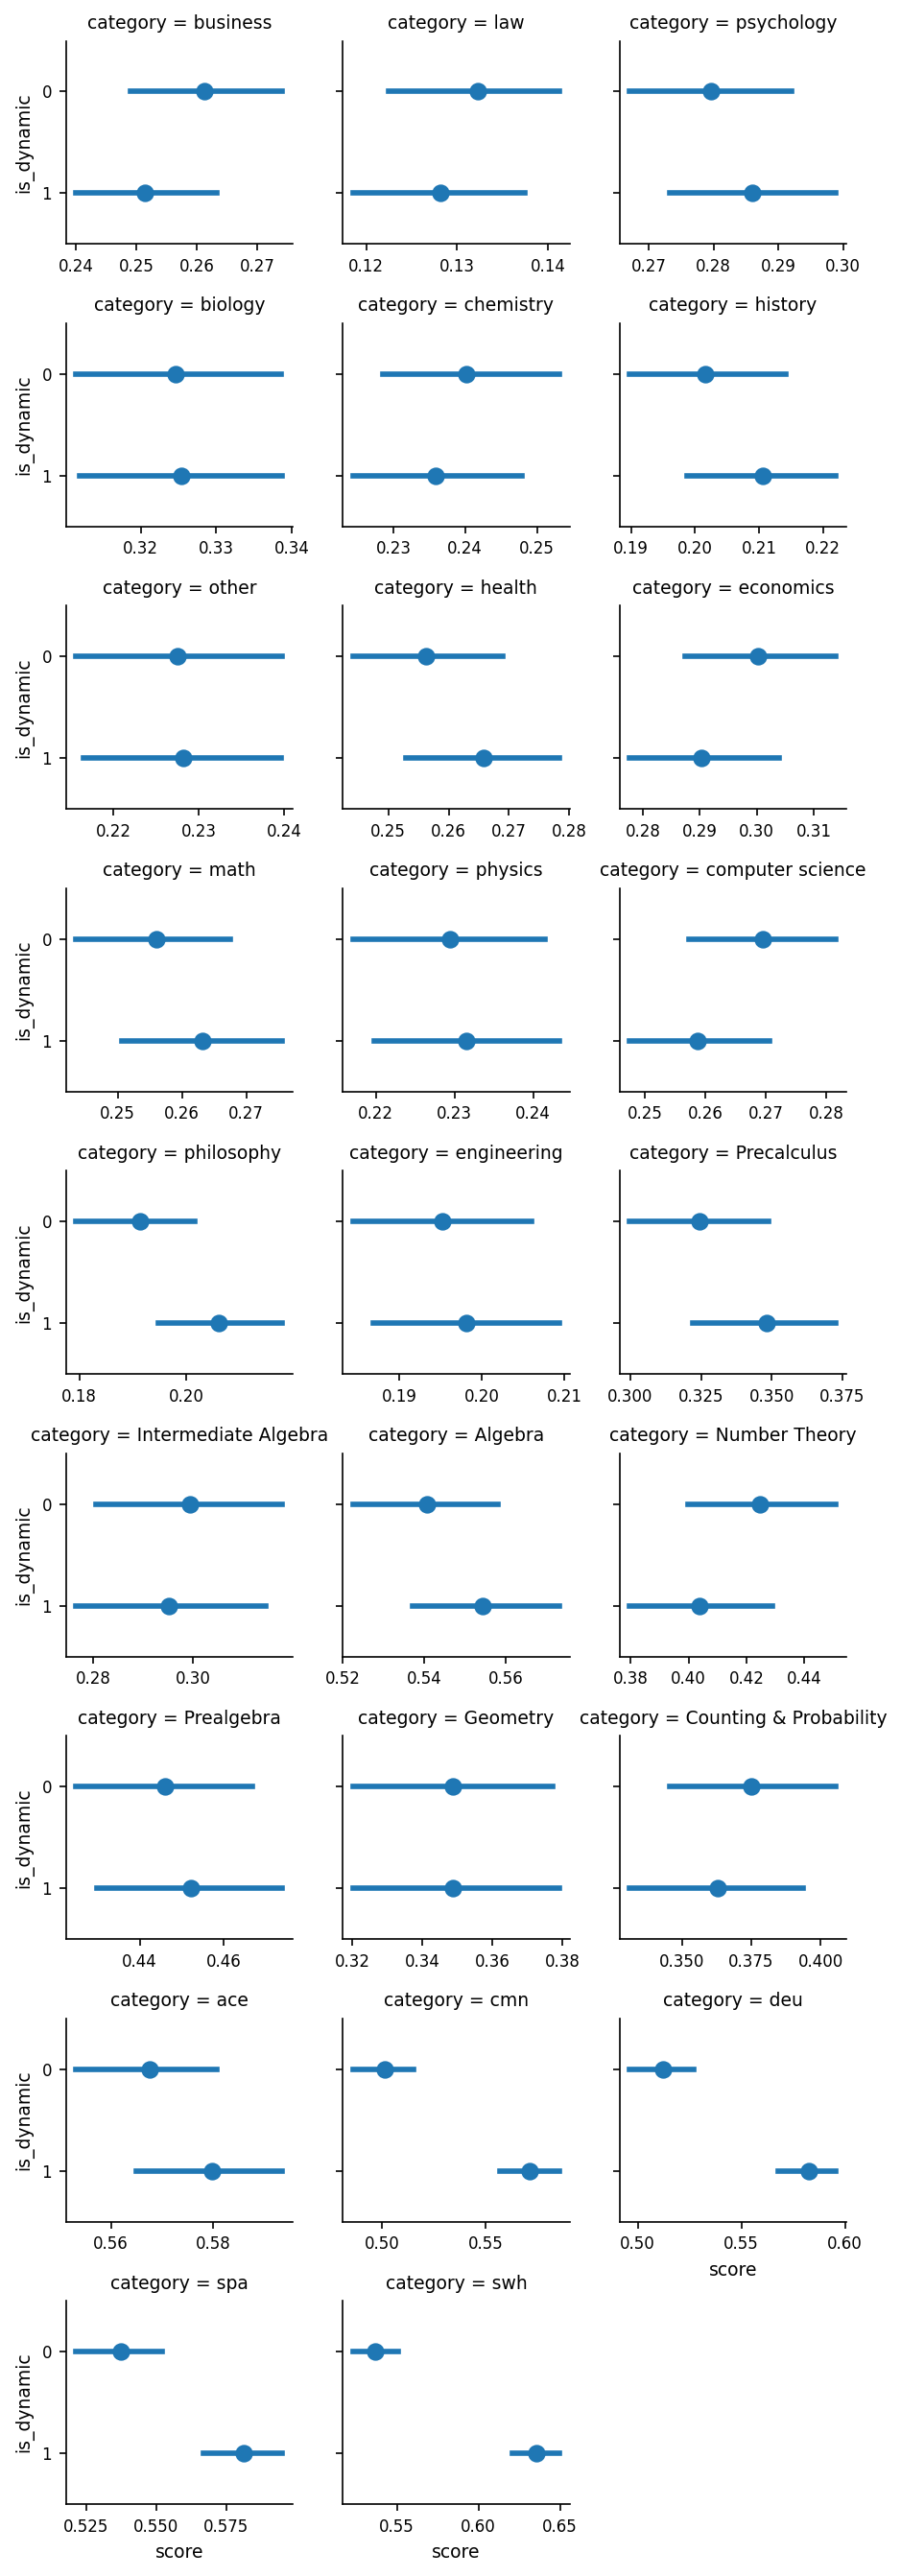

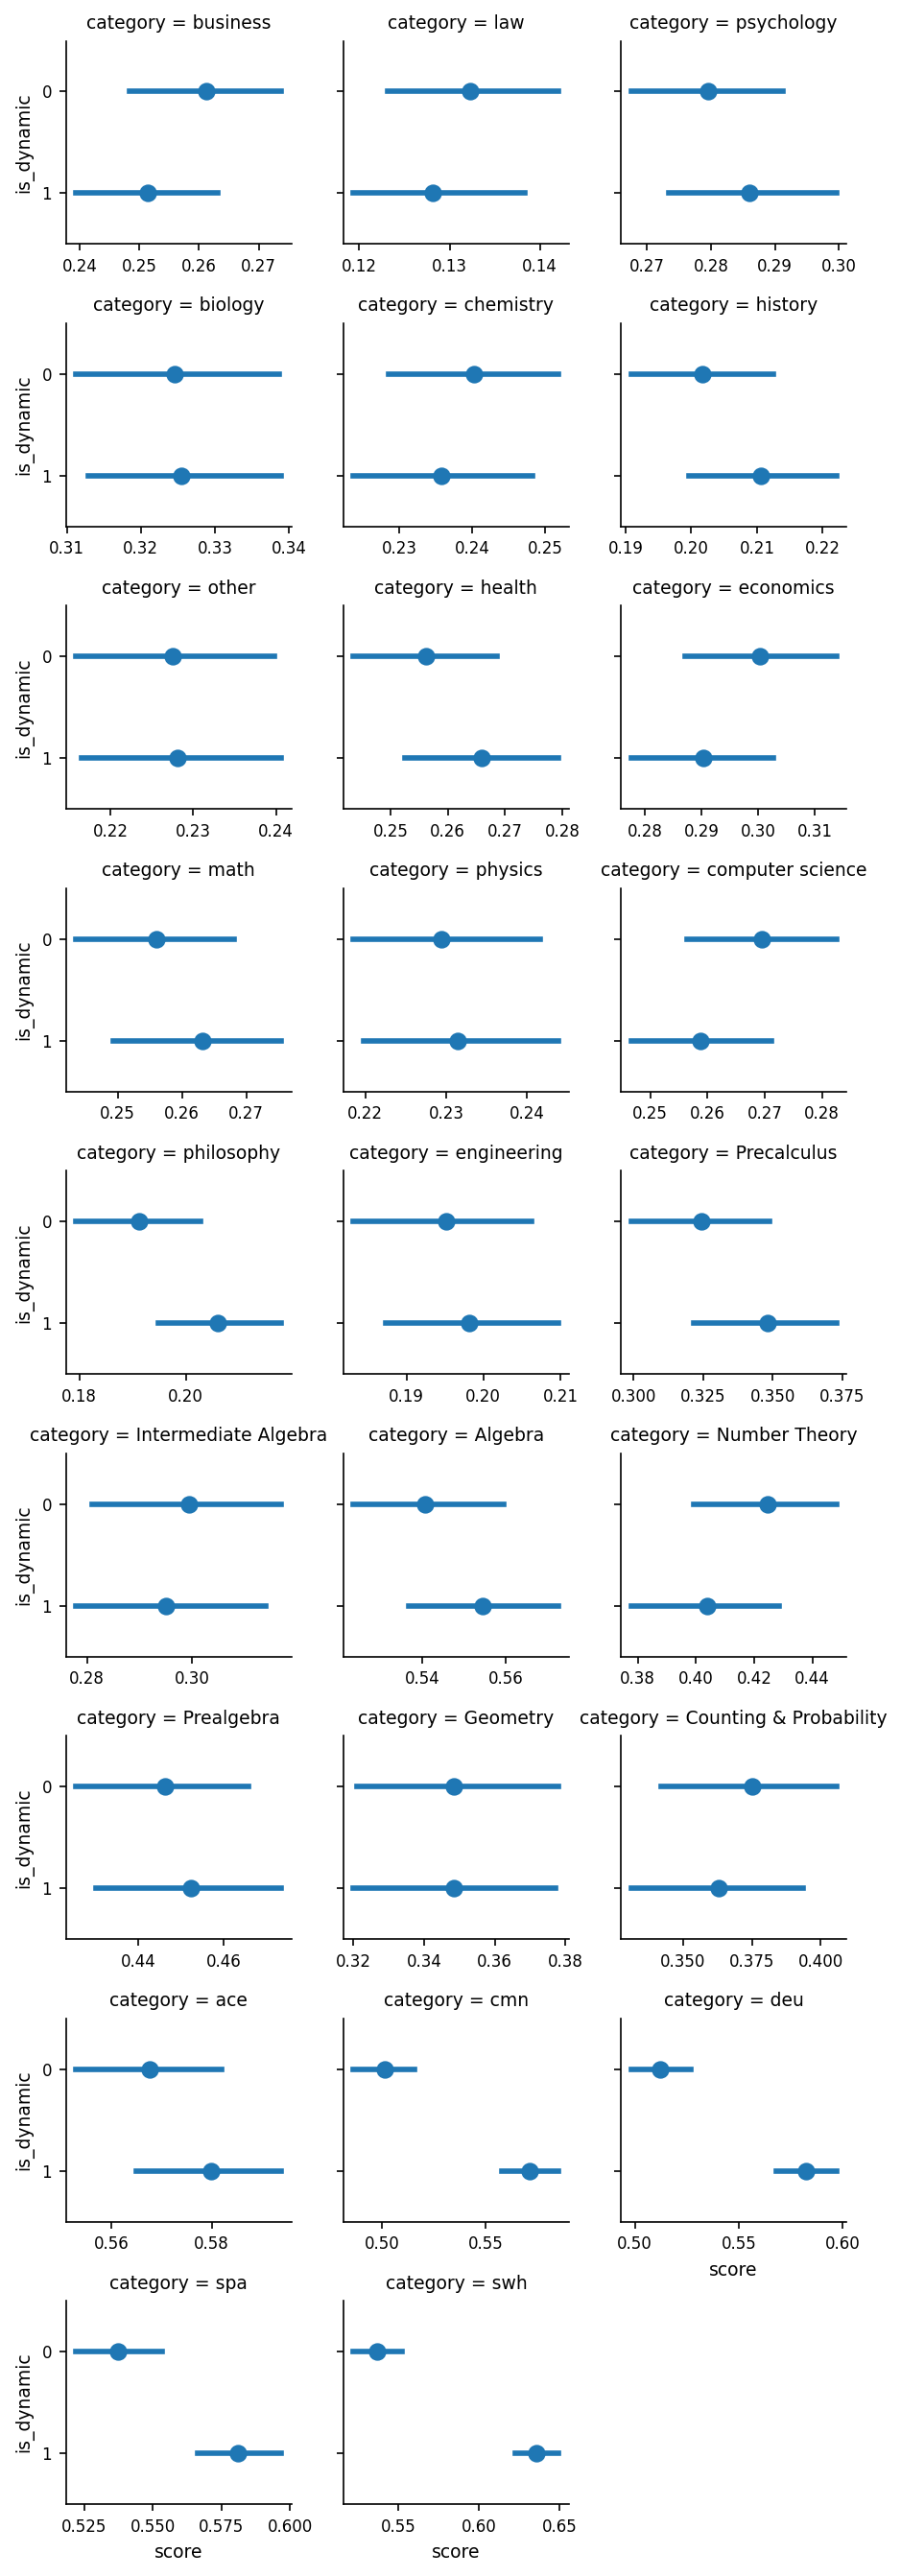

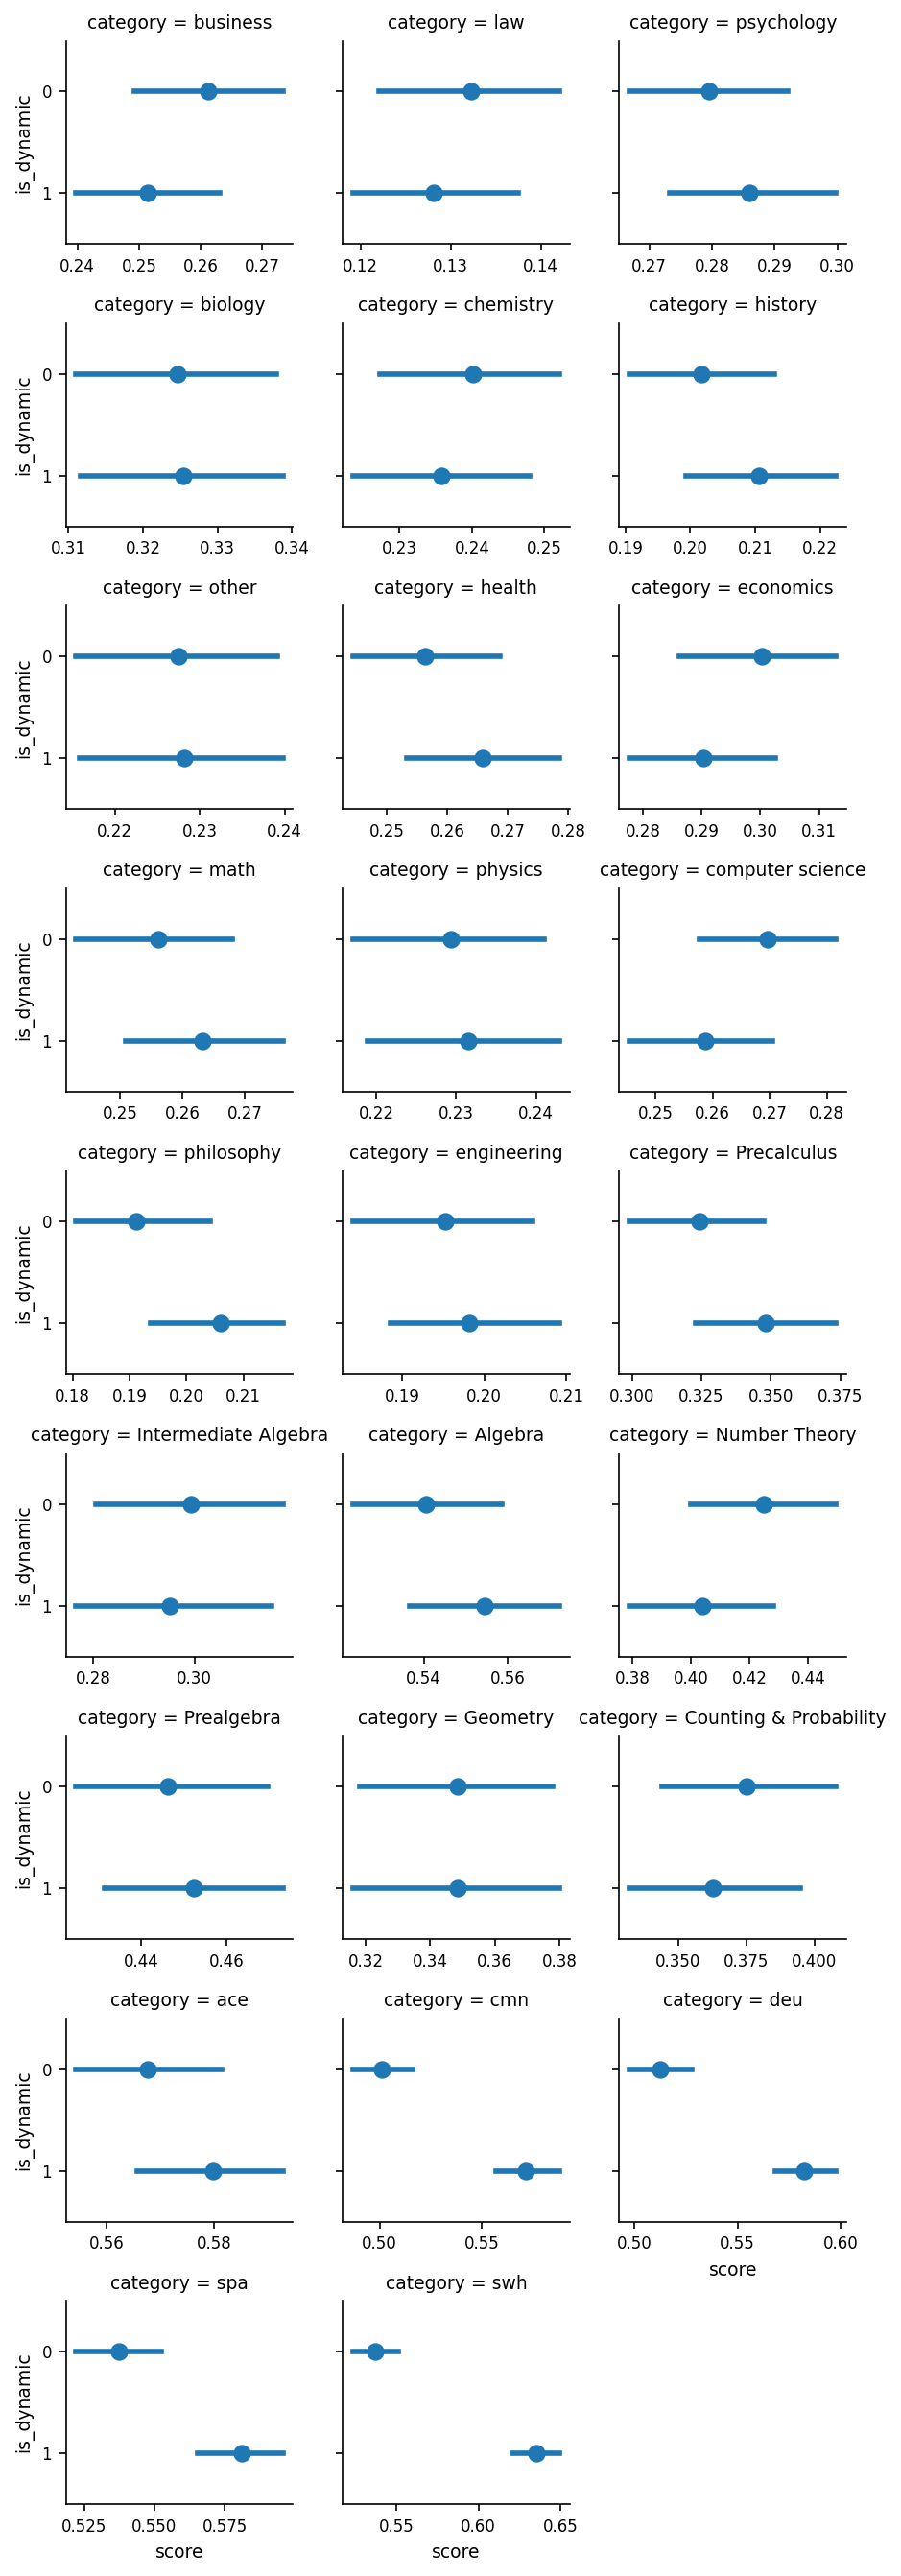

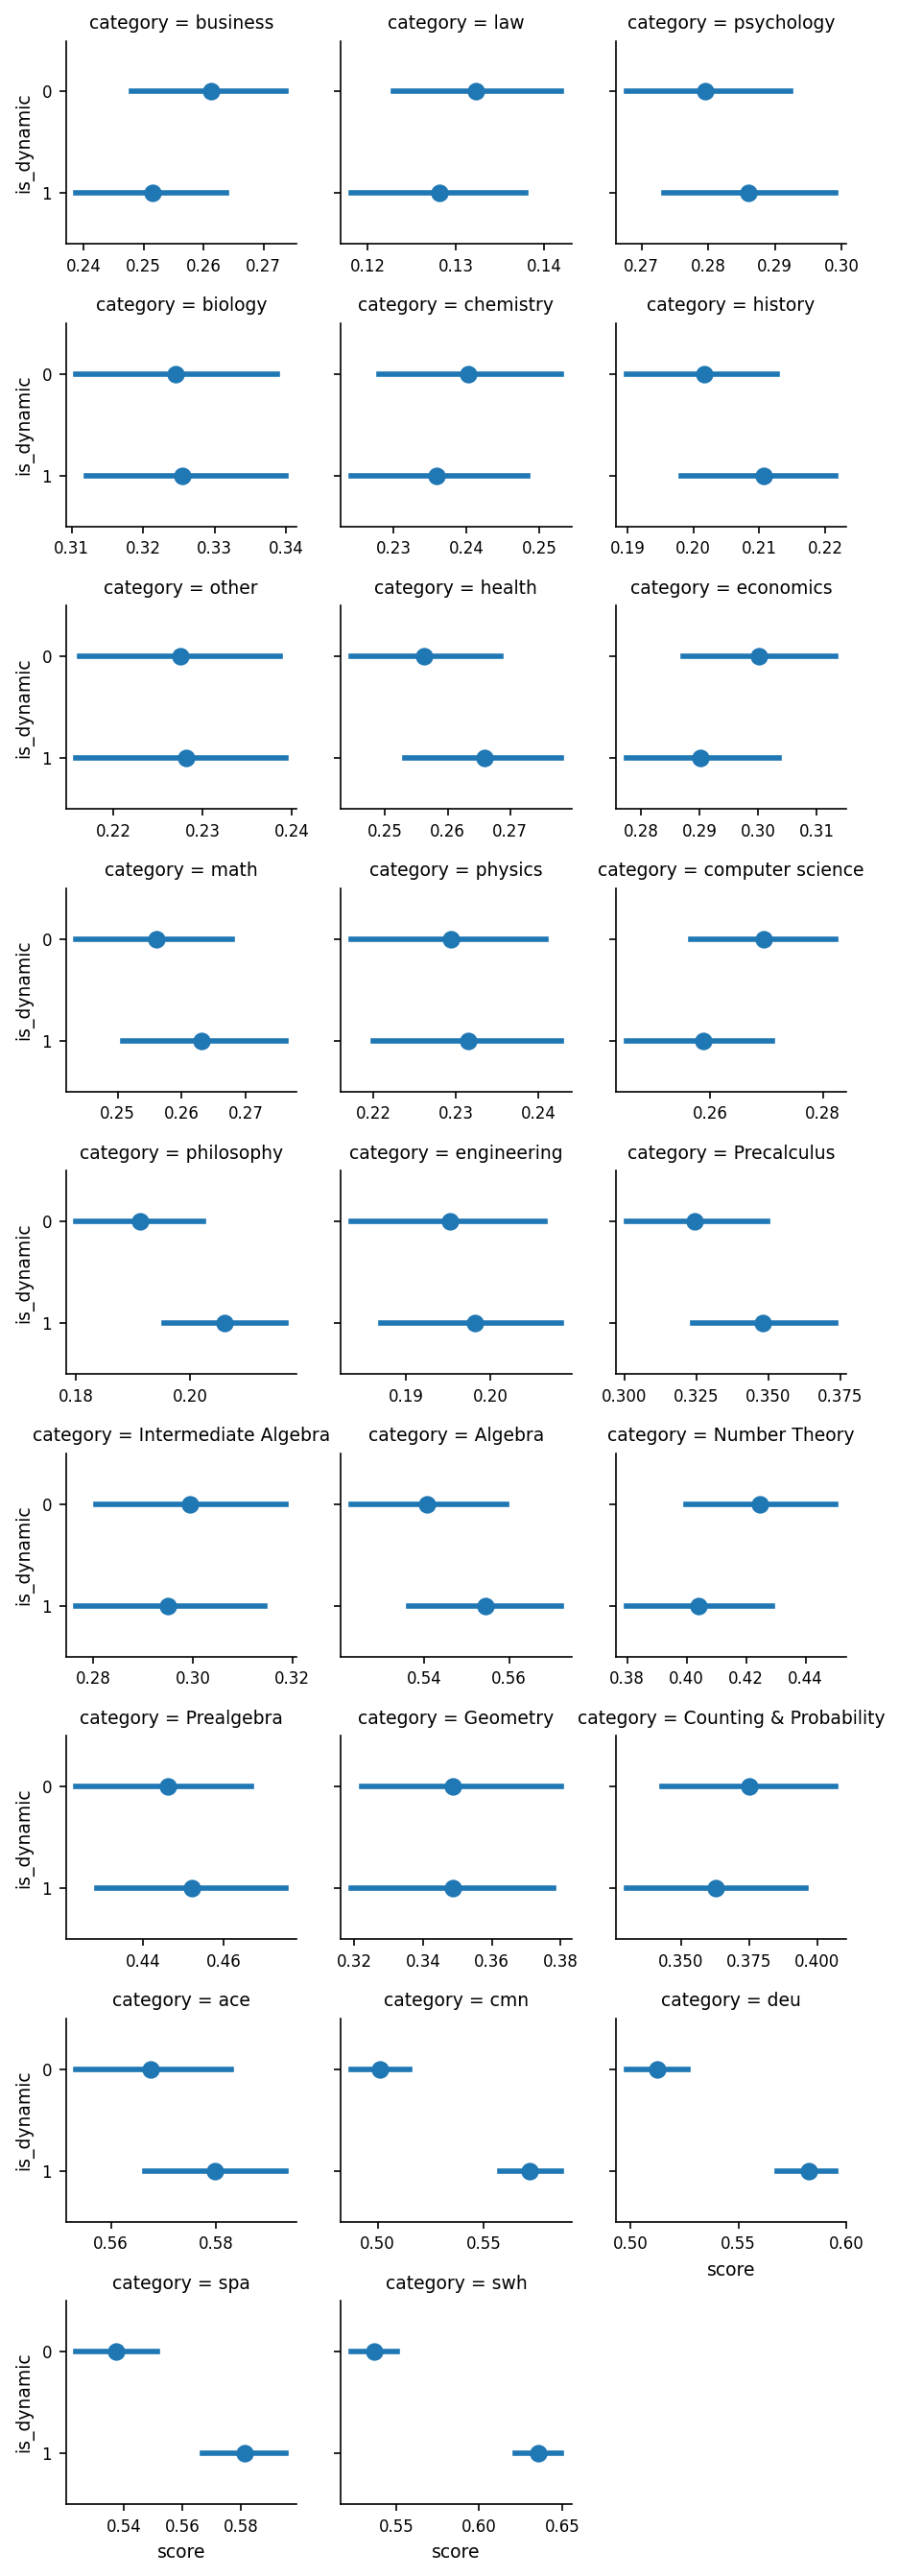

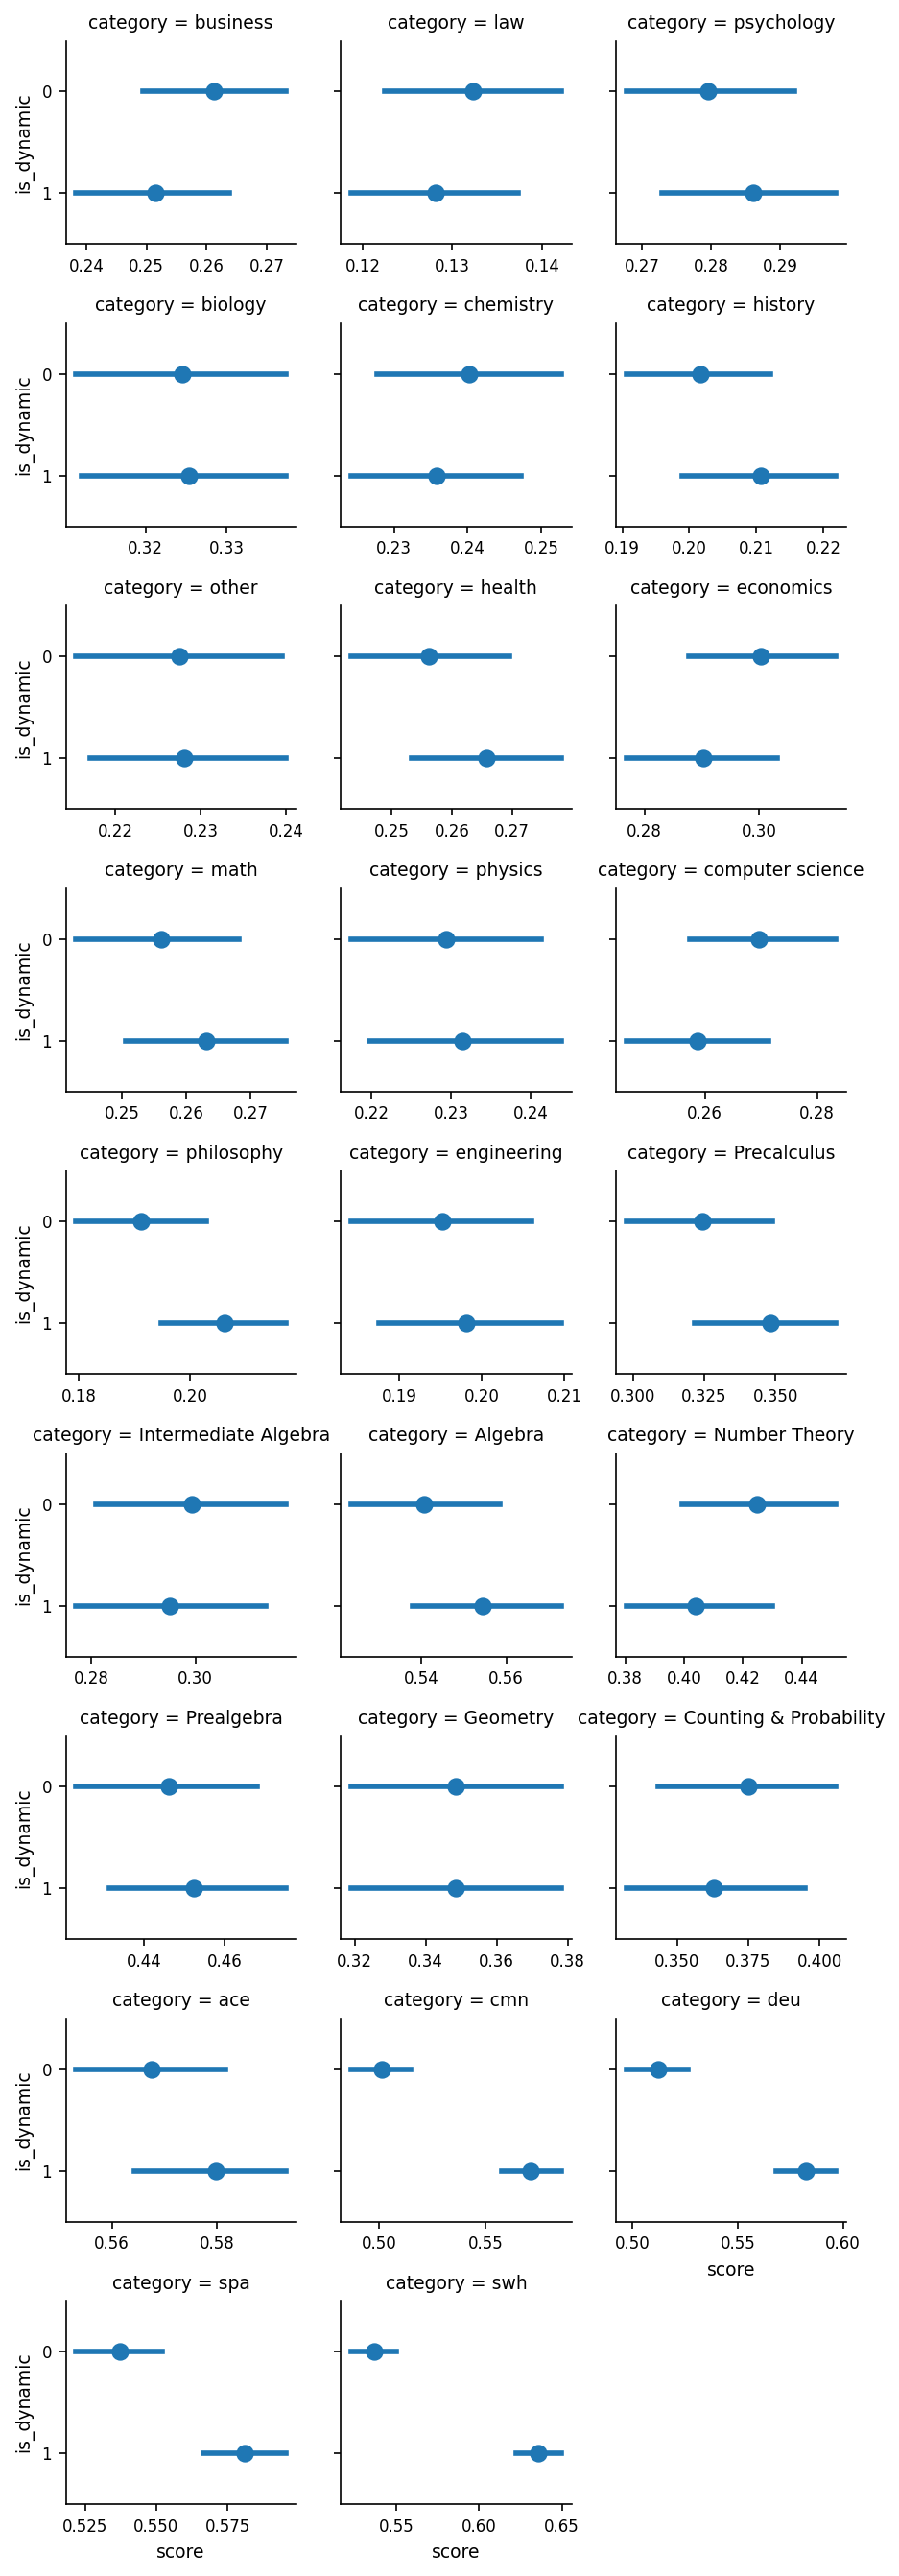

In [121]:
for dataset, dynamic_group_df in dynamic_df.groupby("dataset"):
    sns.catplot(dynamic_df, col="category", y="is_dynamic", x="score", kind="point", orient="h", col_wrap=3, sharex=False, height=2, linestyle="none")

In [123]:
print_sig(tests_dynamic_df, "category")

 === MATH ===
    === Algebra
    === Counting & Probability
    === Geometry
    === Intermediate Algebra
    === Number Theory
    === Prealgebra
    === Precalculus
 === alpaca ===
 === flores ===
    === ace
    === cmn
    Persona is_dynamic           p-val 0.000 coef 0.279
    === deu
    Persona is_dynamic           p-val 0.000 coef 0.282
    === spa
    Persona is_dynamic           p-val 0.000 coef 0.181
    === swh
    Persona is_dynamic           p-val 0.000 coef 0.405
 === ifbench ===
 === mmlu-pro ===
    === biology
    === business
    === chemistry
    === computer science
    === economics
    === engineering
    === health
    === history
    === law
    === math
    === other
    === philosophy
    Persona is_dynamic           p-val 0.036 coef 0.124
    === physics
    === psychology


# Model Sensitivity

In [62]:
from evaluate import prepare_length

dfs = []
for mode in ["static", "dynamic", "combined"]:
    mode: Literal["static", "dynamic", "combined"] = mode   # to silence warning
    length_df = prepare_length(length_base_df, mode)
    length_df["mode"] = mode
    dfs.append(length_df)
length_df = pd.concat(dfs)

length_mapping = {1: "base", 2: "short", 3: "medium", 4: "long"}
length_df["length"] = length_df["length"].map(length_mapping)
length_df["length"] = pd.Categorical(length_df["length"], categories=length_mapping.values(), ordered=True)

In [63]:
# https://stats.stackexchange.com/questions/331244/how-to-test-if-an-interaction-is-significant-interaction-terms-or-model-compari

In [25]:
dfl = tests_length_df[tests_length_df["category"].isna()]
dfl = dfl[dfl["term"] == "length"]

In [34]:
dfm = tests_length_model_df[tests_length_model_df["term"] == "length"]
dfm

,dataset,category,term,mode,model,coef,stderr,pvalue
1,mmlu-pro,NaN,length,static,gemma-3-1b-it,-0.034091,0.026248,0.194016
3,mmlu-pro,NaN,length,dynamic,gemma-3-1b-it,-0.011283,0.026101,0.665542
5,mmlu-pro,NaN,length,combined,gemma-3-1b-it,-0.015697,0.021521,0.465758
7,mmlu-pro,NaN,length,static,gemma-3-4b-it,-0.037343,0.075847,0.622474
9,mmlu-pro,NaN,length,dynamic,gemma-3-4b-it,0.043730,0.076400,0.567066
...,...,...,...,...,...,...,...,...
273,flores,NaN,length,dynamic,qwen3-0-6b,0.045558,0.027579,0.098562
276,flores,NaN,length,combined,qwen3-0-6b,0.006277,0.022562,0.780854
279,flores,NaN,length,static,qwen3-4b,0.056987,0.027038,0.035059
282,flores,NaN,length,dynamic,qwen3-4b,0.116105,0.027260,0.000021


In [36]:
models = tests_length_model_df["model"].unique()
modes = tests_length_model_df["mode"].unique()
datasets = tests_length_model_df["dataset"].unique()
for model in models:
    agreement = 0
    for mode in modes:
        for dataset in datasets:
            df_l = dfl[(dfl["dataset"] == dataset) & (dfl["mode"] == mode)]
            df_m = dfm[(dfm["dataset"] == dataset) & (dfm["mode"] == mode) & (dfm["model"] == model)]
            sig_dataset = df_l.iloc[0]["pvalue"] < 0.05
            sig_model = df_m.iloc[0]["pvalue"] < 0.05
            if sig_dataset == sig_model:
                agreement += 1
    print(f"Model {model}: agreement {agreement/len(dfl)}")

Model gemma-3-1b-it: agreement 0.4666666666666667
Model gemma-3-4b-it: agreement 0.4666666666666667
Model gpt-4-1-nano: agreement 0.8
Model gpt-5-nano: agreement 0.6
Model llama-3-2-1b-instruct: agreement 0.6
Model llama-3-2-3b-instruct: agreement 0.8
Model qwen3-0-6b: agreement 0.6666666666666666
Model qwen3-4b: agreement 0.6


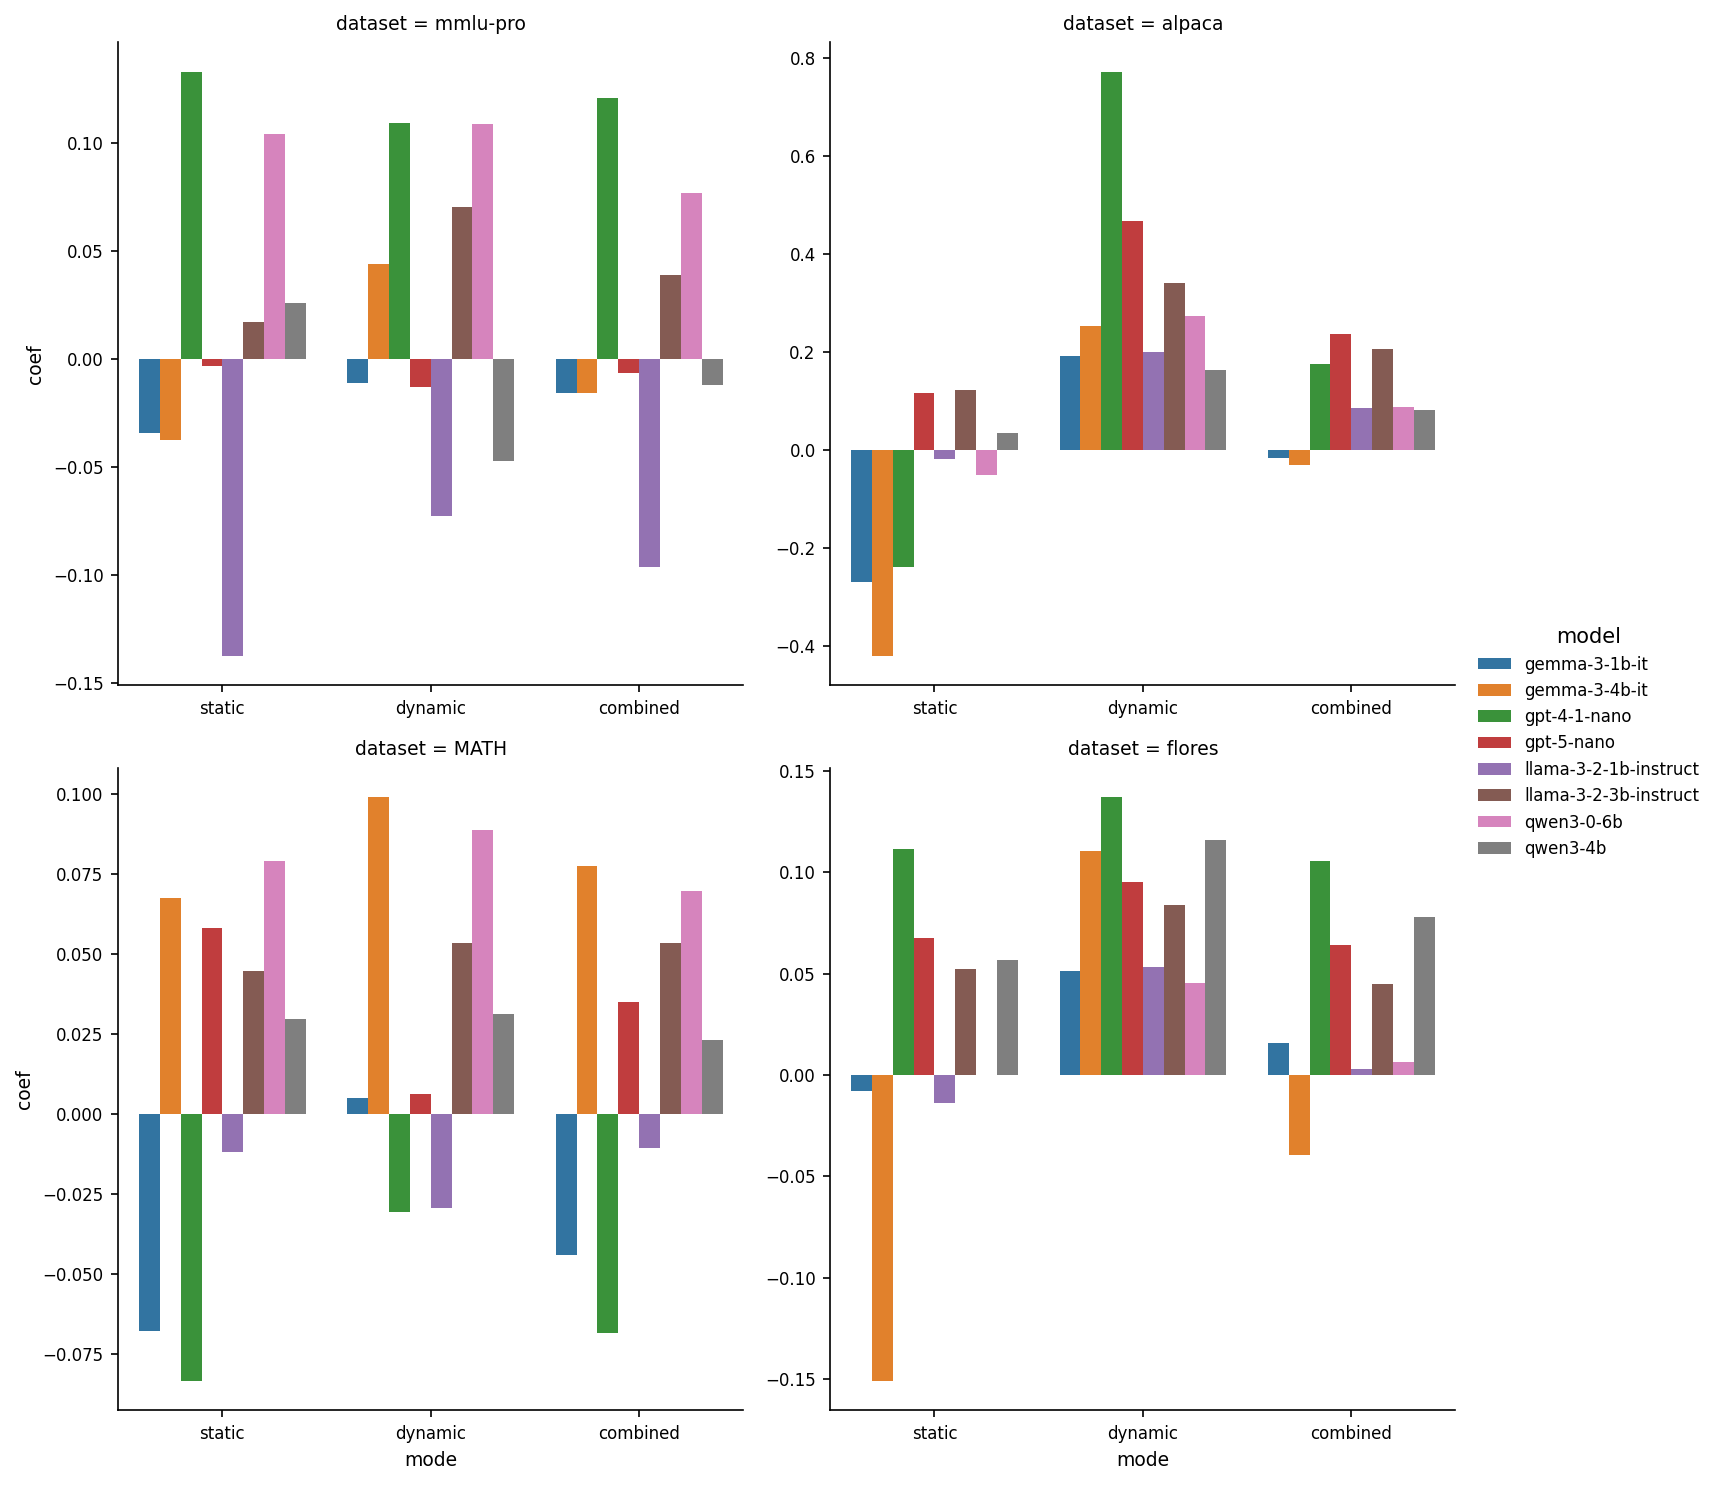

In [89]:
sub_df = tests_length_model_df[tests_length_model_df["term"] == "length"].round(5)
sub_df = sub_df[sub_df["dataset"] != "ifbench"]
# sub_df = sub_df.loc[sub_df["dataset"] == "mmlu-pro"]
# sub_df = sub_df.loc[sub_df["mode"] == "dynamic"]
plot_kwargs = {"sharey": False}
sns.catplot(sub_df, y="coef", col="dataset", kind="bar", x="mode", hue="model", orient="v", col_wrap=2, sharex=False, **plot_kwargs)

In [49]:
sig_model_df = tests_length_model_df[tests_length_model_df["pvalue"] < 0.05]
sig_model_df[sig_model_df["term"]]

,category,term,mode,coef,stderr,pvalue
dataset,,,,,,
mmlu-pro,NaN,Intercept,static,-1.948280,0.071300,2.127399e-164
mmlu-pro,NaN,gemma-3-4b-it,static,-2.285825,0.215201,2.359403e-26
mmlu-pro,NaN,gpt-4-1-nano,static,0.420707,0.091048,3.824294e-06
mmlu-pro,NaN,gpt-5-nano,static,3.130482,0.089758,1.666814e-266
mmlu-pro,NaN,llama-3-2-1b-instruct,static,-0.730279,0.126647,8.105423e-09
...,...,...,...,...,...,...
flores,NaN,gemma-3-4b-it,combined,0.300493,0.094327,1.444229e-03
flores,NaN,llama-3-2-1b-instruct,combined,0.488297,0.094858,2.637207e-07
flores,NaN,llama-3-2-3b-instruct,combined,0.302449,0.093820,1.265455e-03


In [25]:
tests_length_model_df[tests_length_model_df["pvalue"] < 0.05]

,category,lr_stat,diff,pvalue,mode
dataset,,,,,
mmlu-pro,NaN,55.902398,7.0,9.874614e-10,static
mmlu-pro,NaN,56.690946,7.0,6.885718e-10,dynamic
mmlu-pro,NaN,65.356471,7.0,1.275100e-11,combined
alpaca,NaN,135.153605,7.0,5.257852e-26,static
alpaca,NaN,133.070010,7.0,1.434300e-25,dynamic
alpaca,NaN,60.814963,7.0,1.037620e-10,combined
MATH,NaN,14.237561,7.0,4.711387e-02,combined
flores,NaN,58.444491,7.0,3.083762e-10,static
flores,deu,94.376287,7.0,1.558034e-17,static


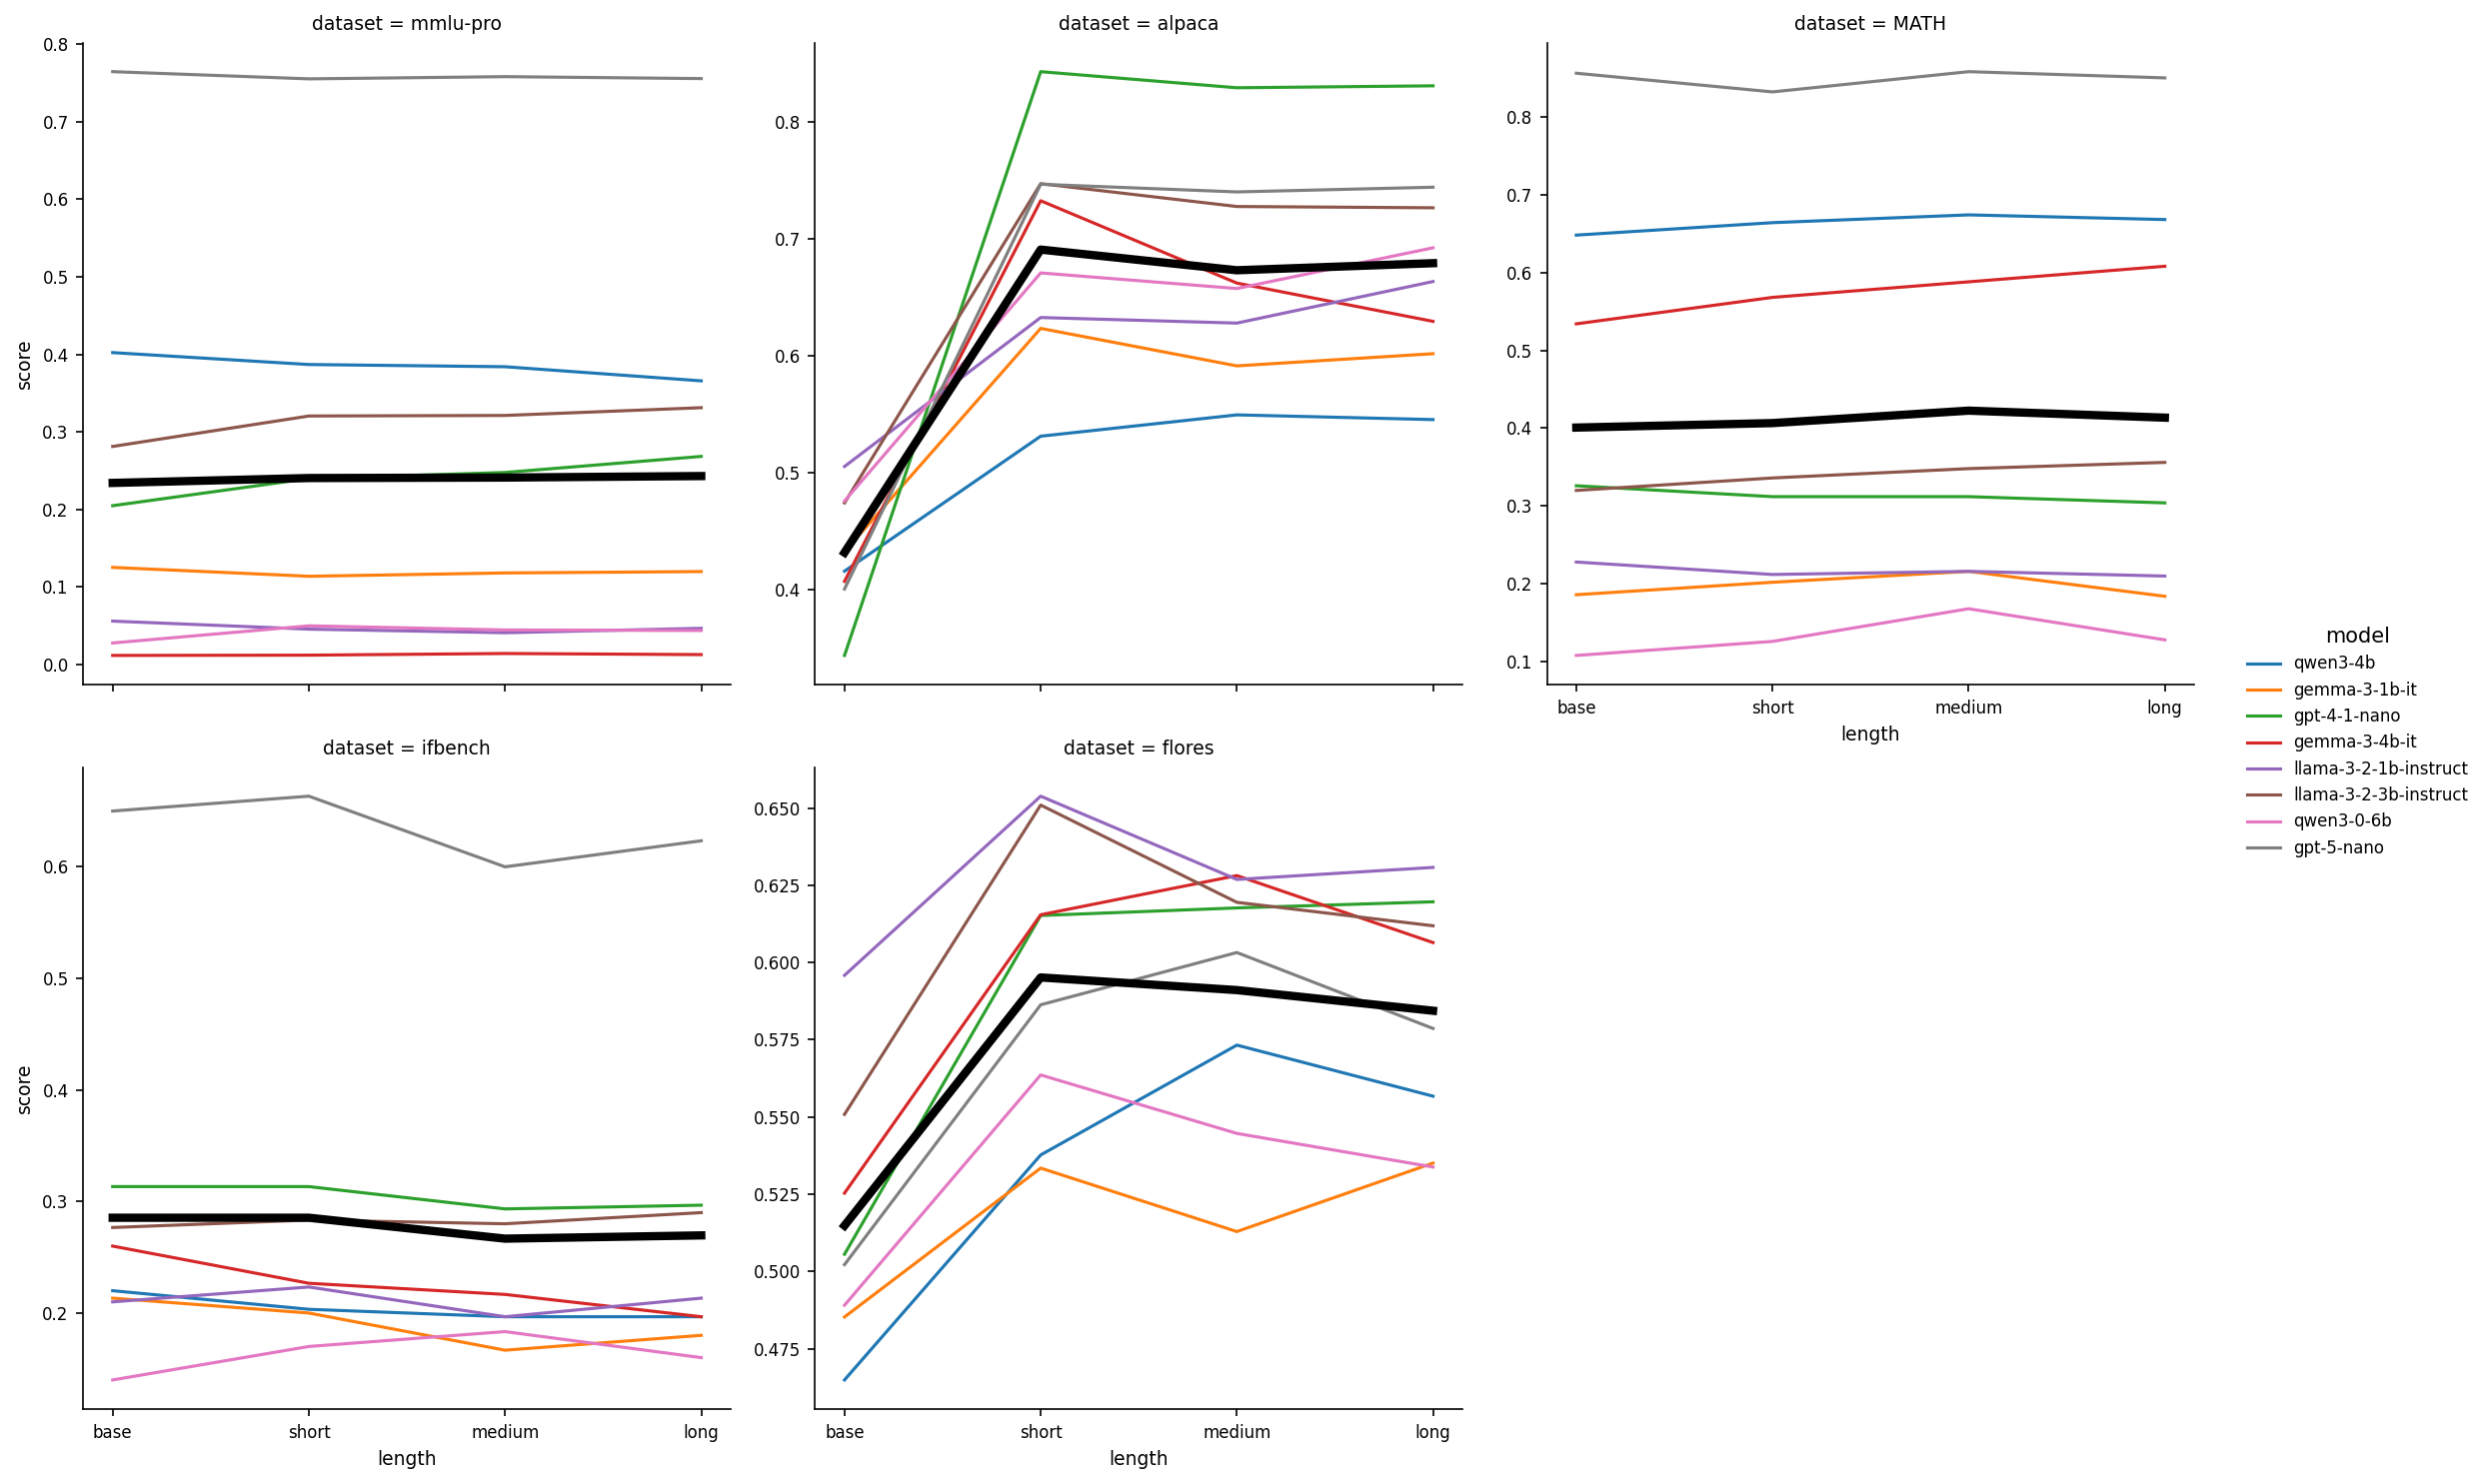

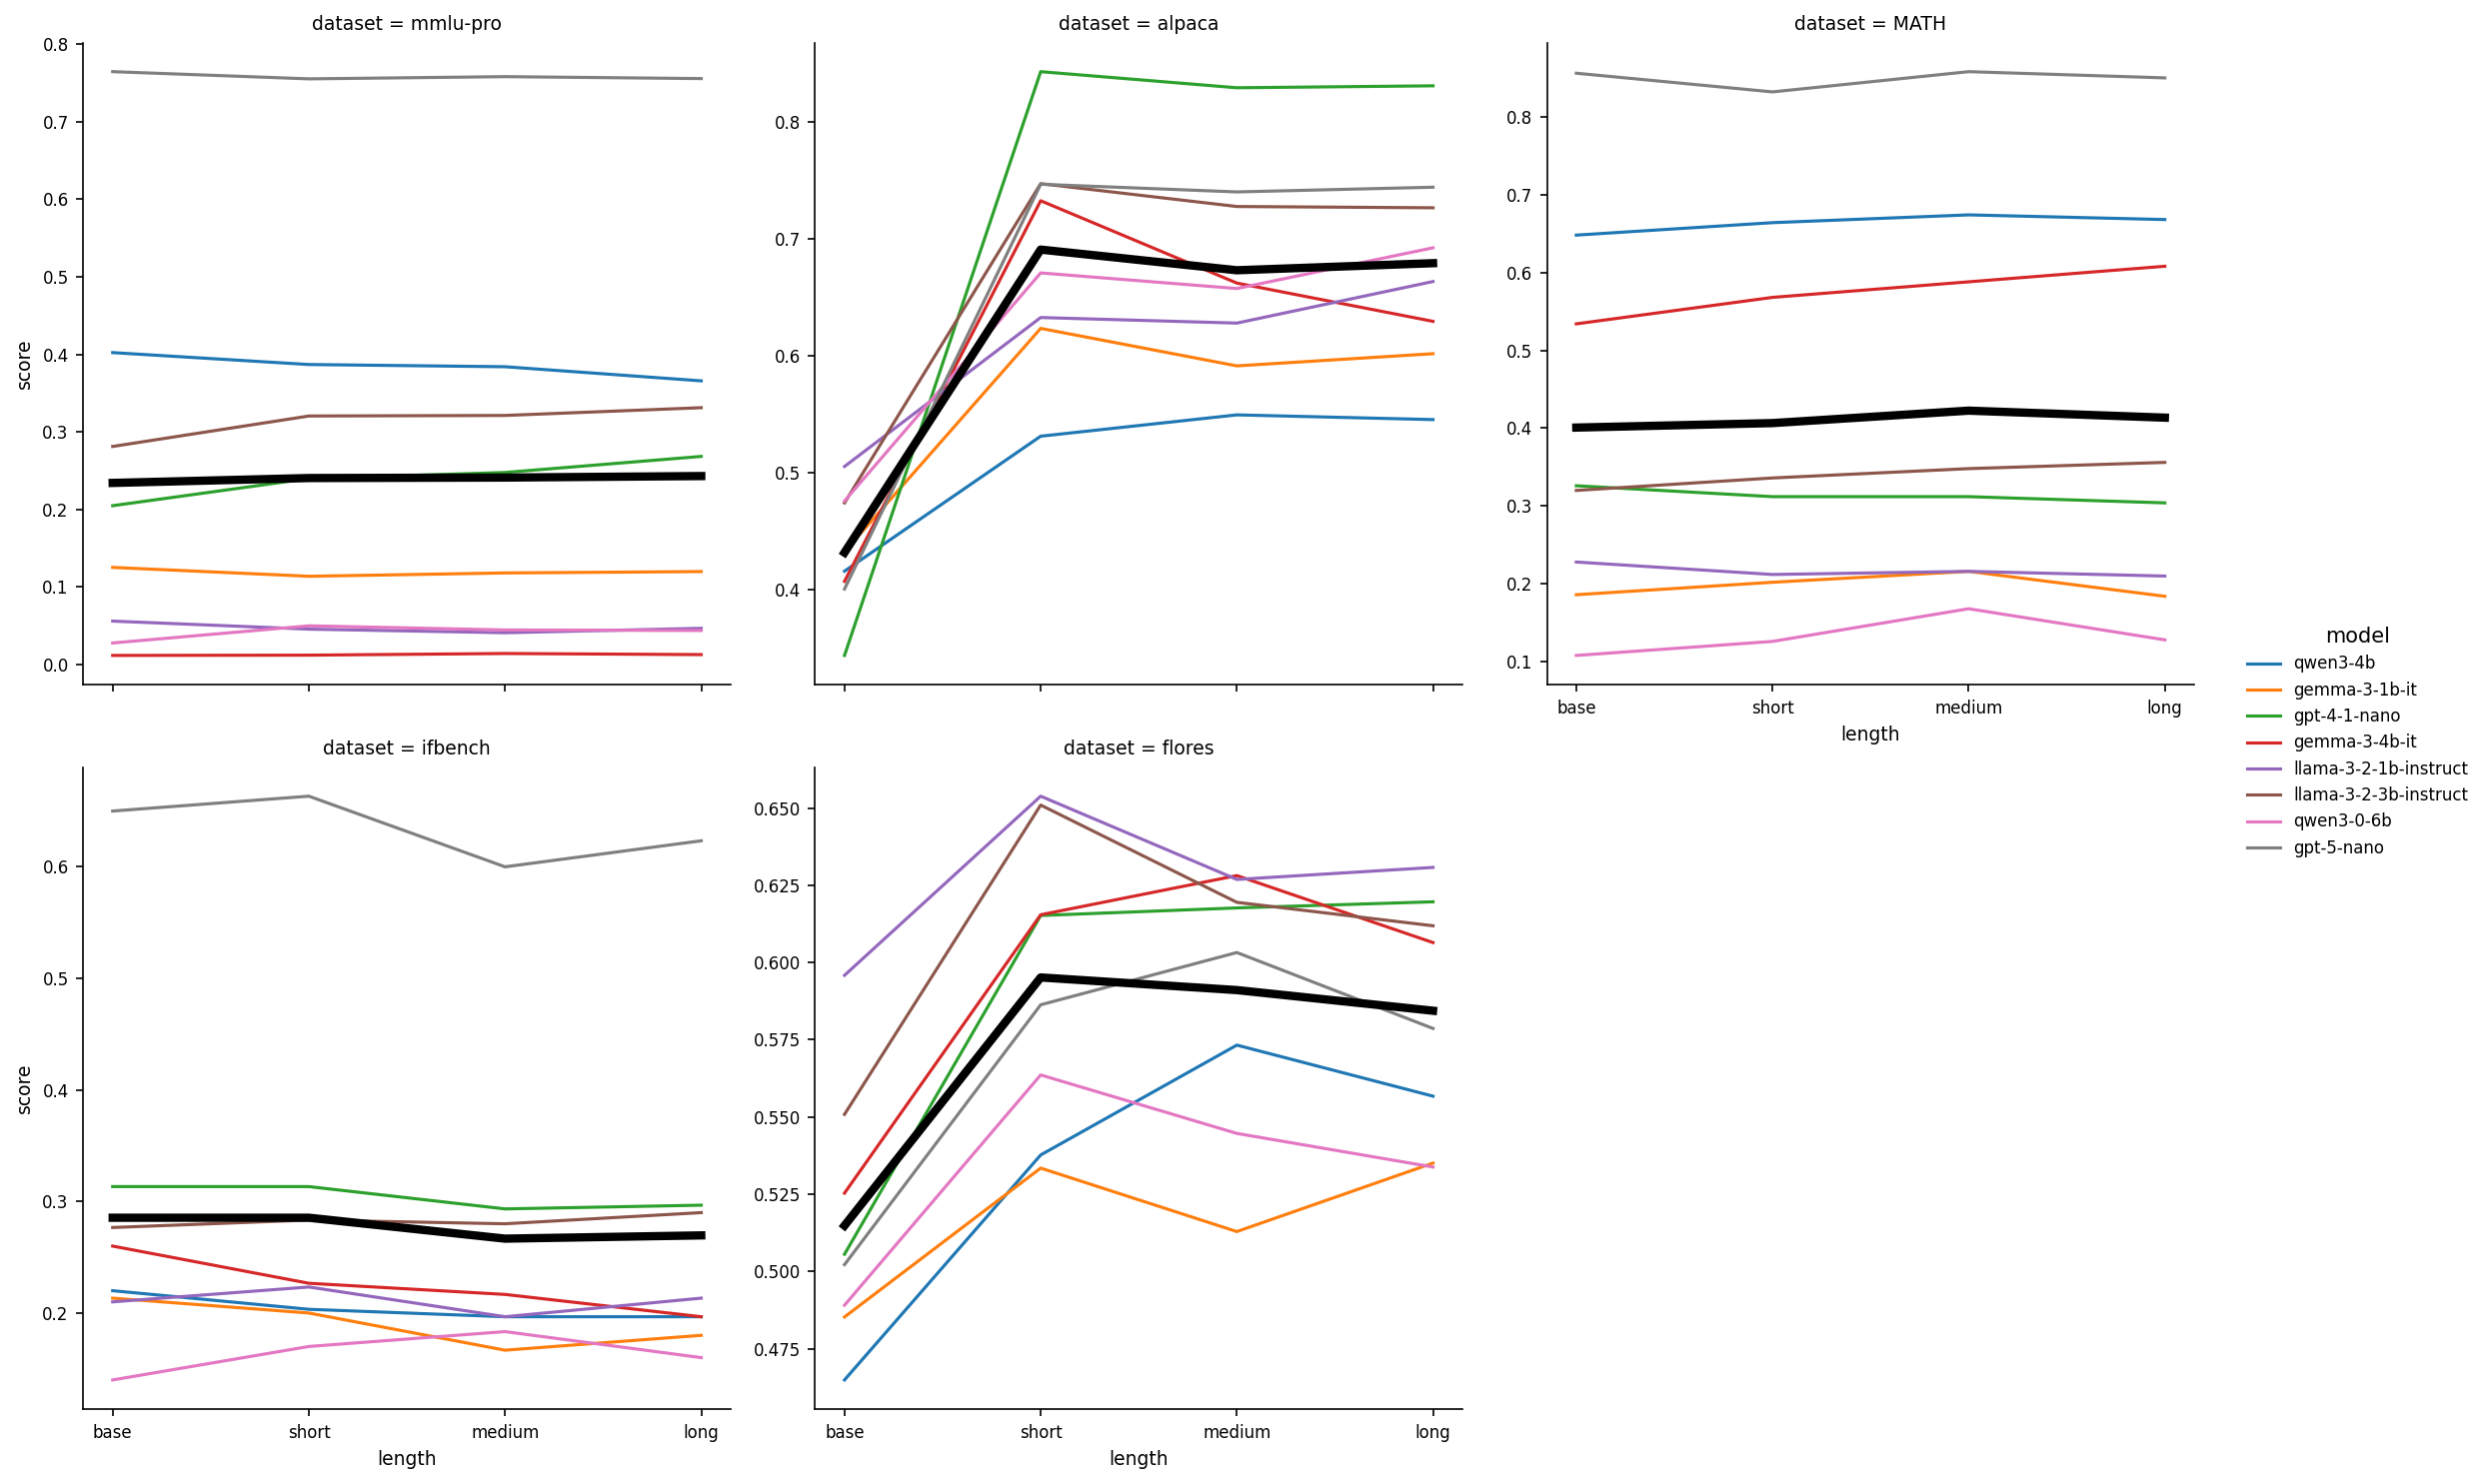

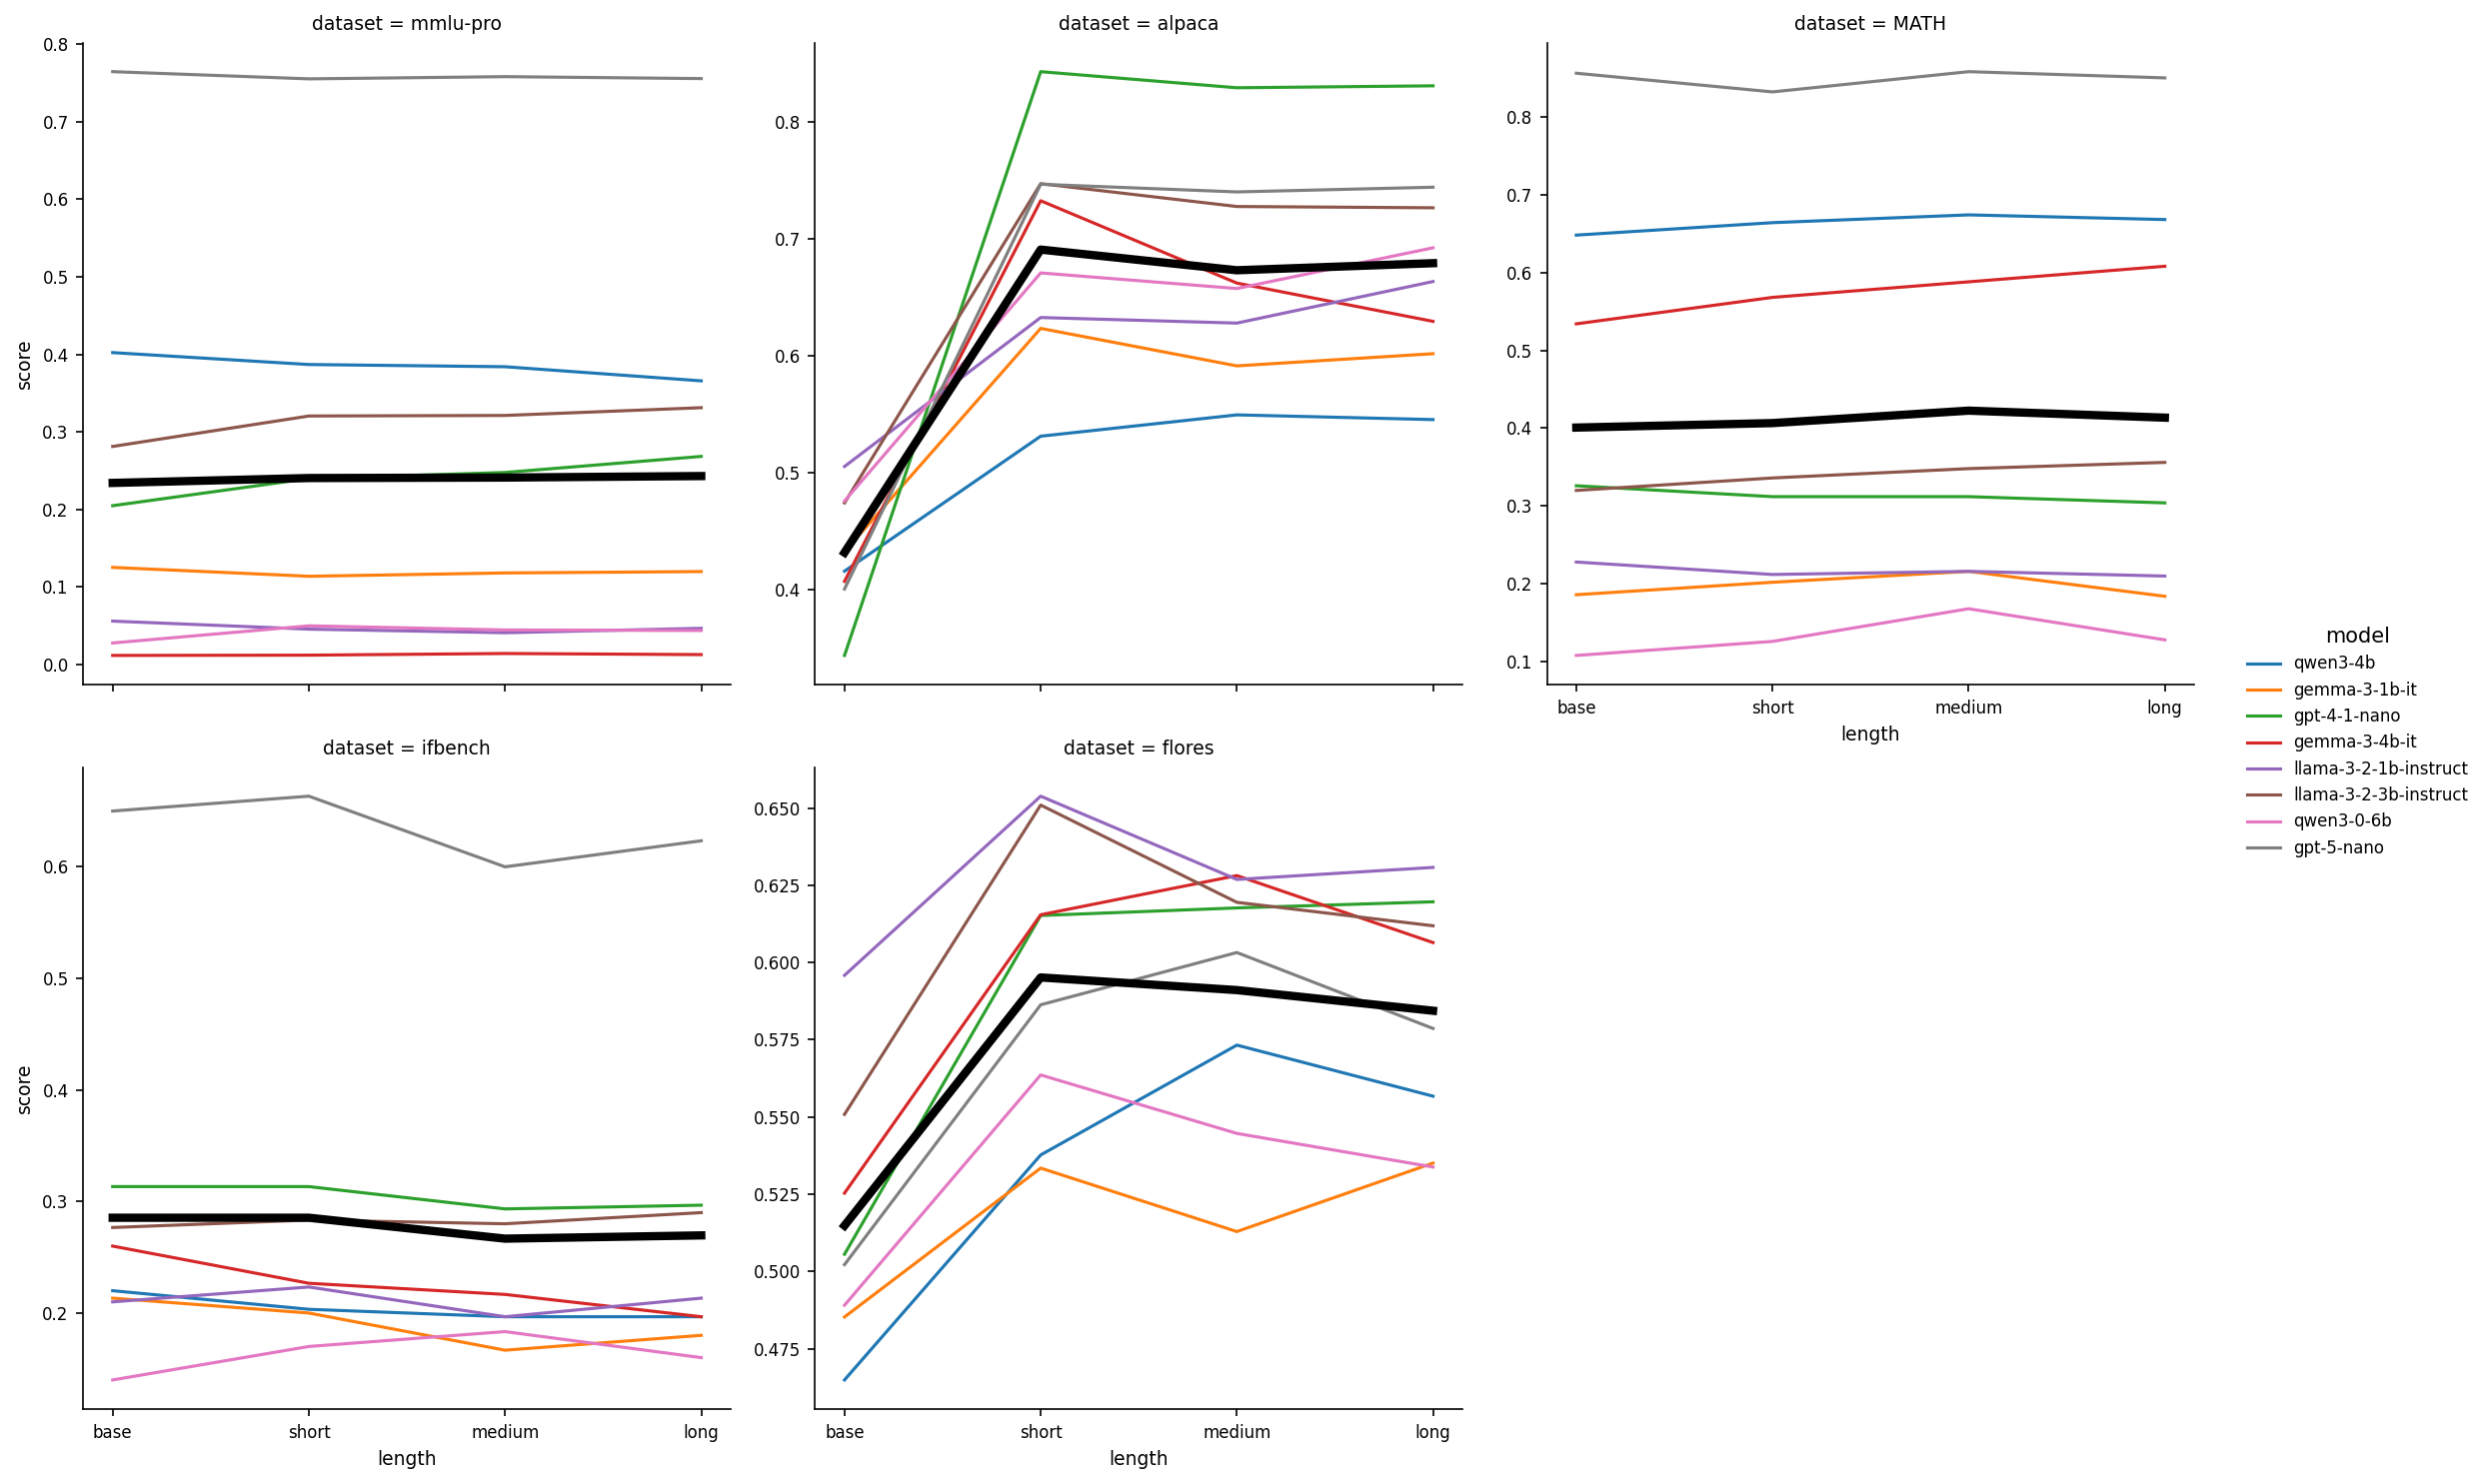

In [22]:
facet_kw = {"sharey": False}
for mode in ["dynamic", "static", "combined"]:
    mode_df = length_df[length_df["mode"] == "dynamic"]

    g = sns.relplot(
        data=mode_df,
        x="length",
        y="score",
        col="dataset",
        hue="model",
        kind="line",
        errorbar=None,     # newer seaborn
        col_wrap=3,
        facet_kws=facet_kw,
    )

    g.map_dataframe(
        sns.lineplot,
        x="length",
        y="score",
        estimator="mean",
        errorbar=None,
        color="black",
        linewidth=4,
        legend=False,
    )
# sns.relplot(mode_df, x="length", y="score", col="dataset", hue="model", kind="line", err_style=None, col_wrap=3, facet_kws=facet_kw)

In [ ]:
def print_sig(sig_df, group_col):
    for dataset_id, dataset_subset in sig_df.groupby("dataset"):
        print(f" === {dataset_id} ===")
        for d_name, sig_group_df in dataset_subset.groupby(group_col):
            print(f"    === {d_name}")
            sig = sig_group_df[sig_group_df["pvalue"] < 0.05]
            for row in sig.itertuples():
                if row.term == "Intercept" or "llama" in row.term or "wen" in row.term or "gpt" in row.term or "gemma" in row.term\
                        or "1/2" in row.term or "no" in row.term or "0" in row.term or "1" in row.term or "2" in row.term:
                    continue
                print(f"    Persona {row.term:<20} p-val {row.pvalue:.3f} coef {row.coef:.3f}")
                if hasattr(row, "mode"):
                    print(row.mode)